# Missing Data Analysis and Treatment

- **Visual inspection** of missing data patterns using `missingno` visualizations.  
- **Forward and backward fill** applied across multiple instances for the same individual.  
- **Drop columns** with more than **40% missing data**.  
- For columns with **5%–40% missing data**:
  - Perform a statistical test.
  - **Drop the column** if the **p-value ≥ 0.1** (not significantly informative).  
- For columns with:
  - **0%–5% missing data**, or  
  - **5%–40% missing data with p-value < 0.1**:  
  → Apply **KNN imputation**.  
- **Text columns** (categorical/string features) are **completed**.
- **verifications**
- **data type adjustments** where necessary.


## Imports

In [1]:
import numpy as np
import pandas as pd
pd.set_option('display.max_columns', None)
#pd.reset_option('display.max_columns')

from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.feature_selection import f_classif

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")
import missingno as msno

import sys
sys.path.append('..')
from scripts.constants import *

## Read dataset

In [2]:
data = pd.read_csv("../data/interim/05. FRAIL_correct_dtypes.csv")
print(data.shape)
data.head()

(6841, 86)


,ID_Aluno,Momento,Local_de_Avaliacao,Data_avaliacao,Data_nascimento,Age,Genero,Modalidade,Freq_semanal,ANTROPOMETRIA_Estatura_cm,ANTROPOMETRIA_Peso_Kg,Escolaridade,Quedas_ultimos_12meses,Quedas_12meses_Quantas,Quedas_12meses_Situacao,Quedas_12meses_Lesao_Sim_Nao,Quedas_12meses_Lesao_Tipo,Quedas_12meses_Lesao_Local,Quedas_12meses_Assistencia_hospitalar_Sim_Não,Quedas_12meses_Hospitalizado_Sim_Não,Quedas_12meses_Hospitalizado_Dias,Quedas_12meses_Medo_cair_Sim_Não,ATIVIDADE_FISICA_Geral_Sim_Não,ATIVIDADE_FISICA_Caminhada_Frequência_Dias_semana,ATIVIDADE_FISICA_Caminhada_Duracao_min_dia,ATIVIDADE_FISICA_Caminhada_Intensidade,ATIVIDADE_FISICA_Outras_AF_Qual,ATIVIDADE_FISICA_Outras_AF_Frequencia_Dias_semana,ATIVIDADE_FISICA_Outras_AF_Duracao_min_dia,ATIVIDADE_FISICA_Outras_AF_Intensidade,ANTROPOMETRIA_Massa_gorda,ANTROPOMETRIA_Massa_magra_Kg,ANTROPOMETRIA_Gordura_visceral,HANDGRIP_Mao_DOMINANTE,HANDGRIP_DIREITA_tentaiva1,HANDGRIP_DIREITA_tentativa2,HANDGRIP_DIREITA_tentativa_3,HANDGRIP_ESQUERDA_tentativa1,HANDGRIP_ESQUERDA_tentativa2,HANDGRIP_ESQUERDA_tentativa3,TIMED_UP_AND_GO_Simples_tentativa1,TIMED_UP_AND_GO_Simples_tentativa2,Best_TIMED_UP_AND_GO_Simples,Percentil_TIMED_UP_AND_GO_Simples,TIMED_UP_AND_GO_Simples_Apoio_mãos,TIMED_UP_AND_GO_Simples_Auxiliar_marcha,TIMED_UP_AND_GO_Dupla_tarefa_tentativa1,TIMED_UP_AND_GO_Dupla_tarefa_tentativa2,Best_TIMED_UP_AND_GO_Dupla_tarefa,Percentil_TIMED_UP_AND_GO_Dupla_tarefa,TIMED_UP_AND_GO_Dupla_tarefa_Apoio_maos,TIMED_UP_AND_GO_Dupla_tarefa_Auxiliar_marcha,SIT_TO_STAND_Repetiçoes,Percentil_SIT_TO_STAND_Repetiçoes,SIT_TO_STAND_Apoio_maos,SIT_TO_STAND_Auxiliar_marcha,@6_MIN_ANDAR_Percurso,@6_MIN_ANDAR_N_voltas_completas,@6_MIN_ANDAR_Resultado_teste_Metros,@6_MIN_ANDAR_Distancia_TOTAL_metros,Percentil_@6_MIN_ANDAR_Distancia_TOTAL_metros,@6_MIN_ANDAR_Auxiliar_marcha,@6_MIN_ANDAR_Parou,@6_MIN_ANDAR_Parou_Quantas_vezes,@6_MIN_ANDAR_Parou_Motivo,@6_MIN_ANDAR_Desistiu,MMSE_EDUCAÇAO,MMSE_ORIENTACAO_TEMPORAL,MMSE_ORIENTACAO_ESPACIAL,MMSE_RETENCAO,MMSE_ATENCAO_CALCULO,MMSE_EVOCACAO_1,MMSE_LINGUAGEM_A_NOMEACAO,MMSE_LINGUAGEM_B_REPETICAO,MMSE_LINGUAGEM_C_COMANDO,MMSE_LINGUAGEM_D_LEITURA,MMSE_LINGUAGEM_E_FRASE_ESCRITA,MMSE_COPIA_DESENHO_1,MMSE_Total,EQ5D5L_MOBILIDADE,EQ5D5L_CUIDADOS_PESSOAIS,EQ5D5L_ATIVIDADES_HABITUAIS,EQ5D5L_DOR_MAL_ESTAR,EQ5D5L_ANSIEDADE_DEPRESSAO,EQ5D5L_A_sua_saude_hoje_0_100,HANDGRIP_DIREITA_tentativa_2
0,19,1,1,2021-11-16,1941-08-20,80.0,0,1.0,2.0,153.0,59.2,NaN,1.0,1.0,caminhar,1.0,ferida,joelho,0.0,0.0,NaN,1.0,1.0,6.0,40.0,1.0,NaN,NaN,NaN,NaN,38.3,25.0,NaN,1.0,12.3,12.4,12.0,11.4,12.3,12.6,10.33,11.96,10.33,3.0,0.0,0.0,14.90,13.98,13.98,2.0,0.0,0.0,15.0,4.0,0.0,0.0,0.0,12.0,0.0,540.0,5.0,NaN,NaN,NaN,NaN,NaN,12.0,3.0,3.0,3.0,1.0,0.0,2.0,1.0,1.0,1.0,1.0,0.0,16.0,1.0,1.0,1.0,1.0,2.0,80.0,12.0
1,19,3,1,2022-11-16,1941-08-20,81.0,0,1.0,2.0,152.0,57.7,NaN,1.0,1.0,caminhar,1.0,NaN,anca,0.0,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.4,35.4,10.0,1.0,11.2,11.3,12.9,11.9,12.8,11.3,9.24,8.45,8.45,3.0,0.0,0.0,10.83,10.67,10.67,2.0,0.0,0.0,15.0,4.0,0.0,0.0,0.0,11.0,NaN,495.0,4.0,0.0,0.0,NaN,NaN,NaN,NaN,2.0,2.0,3.0,5.0,0.0,2.0,1.0,3.0,1.0,1.0,0.0,20.0,2.0,2.0,2.0,2.0,1.0,80.0,12.9
2,19,4,1,2023-06-20,1941-08-20,81.0,0,1.0,2.0,153.0,56.3,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34.5,35.0,10.0,1.0,8.0,8.0,7.0,4.0,3.0,3.0,10.40,9.60,9.60,3.0,1.0,0.0,16.00,15.00,15.00,2.0,1.0,0.0,10.5,3.0,0.0,NaN,NaN,9.0,20.0,470.0,4.0,0.0,0.0,NaN,NaN,NaN,NaN,2.0,4.0,0.0,4.0,0.0,2.0,1.0,2.0,0.0,1.0,0.0,16.0,1.0,1.0,1.0,2.0,1.0,90.0,7.0
3,37,1,1,2021-11-16,1948-11-20,72.0,0,1.0,2.0,149.0,81.3,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,45.7,25.0,NaN,1.0,22.2,20.0,22.9,13.2,13.7,18.6,9.08,9.76,9.08,1.0,0.0,0.0,13.79,11.80,11.80,0.0,0.0,0.0,11.0,1.0,0.0,0.0,0.0,8.0,35.0,395.0,1.0,NaN,NaN,NaN,NaN,NaN,4.0,0.0,4.0,3.0,5.0,0.0,2.0,1.0,3.0,1.0,1.0,0.0,20.0,1.0,1.0,1.0,1.0,2.0,100.0,22.9
4,37,2,1,2022-06-29,1948-11-20,73.0,0,1.0,2.0,150.0,81.4,NaN,0.0,0

In [3]:
data.columns

Index(['ID_Aluno', 'Momento', 'Local_de_Avaliacao', 'Data_avaliacao',
       'Data_nascimento', 'Age', 'Genero', 'Modalidade', 'Freq_semanal',
       'ANTROPOMETRIA_Estatura_cm', 'ANTROPOMETRIA_Peso_Kg', 'Escolaridade',
       'Quedas_ultimos_12meses', 'Quedas_12meses_Quantas',
       'Quedas_12meses_Situacao', 'Quedas_12meses_Lesao_Sim_Nao',
       'Quedas_12meses_Lesao_Tipo', 'Quedas_12meses_Lesao_Local',
       'Quedas_12meses_Assistencia_hospitalar_Sim_Não',
       'Quedas_12meses_Hospitalizado_Sim_Não',
       'Quedas_12meses_Hospitalizado_Dias', 'Quedas_12meses_Medo_cair_Sim_Não',
       'ATIVIDADE_FISICA_Geral_Sim_Não',
       'ATIVIDADE_FISICA_Caminhada_Frequência_Dias_semana',
       'ATIVIDADE_FISICA_Caminhada_Duracao_min_dia',
       'ATIVIDADE_FISICA_Caminhada_Intensidade',
       'ATIVIDADE_FISICA_Outras_AF_Qual',
       'ATIVIDADE_FISICA_Outras_AF_Frequencia_Dias_semana',
       'ATIVIDADE_FISICA_Outras_AF_Duracao_min_dia',
       'ATIVIDADE_FISICA_Outras_AF_Intensidade',

               section  n_features  missing_pct
0  Timed Up & Go (TUG)          12     1.572626
1             Handgrip           8     1.628051
2         Sit-to-Stand           4     2.145154
3        Anthropometry           5     6.607221
4   Admin/Demographics          10     7.273790
5             EQ-5D-5L           6    18.562101
6                 MMSE          13    26.726862
7        6-minute walk          10    33.227598
8                Falls          10    61.290747
9    Physical activity           8    90.376042


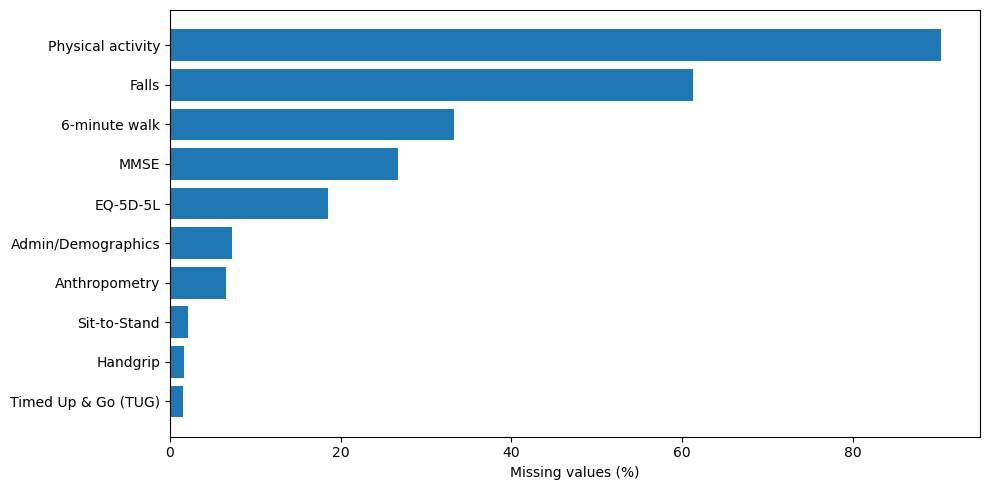

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load
data = pd.read_csv("../data/interim/05. FRAIL_correct_dtypes.csv")
cols = list(data.columns)

def by_prefix(prefixes):
    if isinstance(prefixes, str):
        prefixes = [prefixes]
    return [c for c in cols if any(c.startswith(p) for p in prefixes)]

# --- Section definitions (auto via naming conventions) ---
sections = {
    "Admin/Demographics": [c for c in cols if c in [
        "ID_Aluno", "Momento", "Local_de_Avaliacao", "Data_avaliacao",
        "Data_nascimento", "Age", "Genero", "Modalidade", "Freq_semanal", "Escolaridade"
    ]],
    "Anthropometry": by_prefix("ANTROPOMETRIA_"),
    "Falls": by_prefix("Quedas_"),
    "Physical activity": by_prefix("ATIVIDADE_FISICA_"),
    "Handgrip": by_prefix("HANDGRIP_"),
    "Timed Up & Go (TUG)": [c for c in cols if (
        c.startswith("TIMED_UP_AND_GO_") or c.startswith("Best_TIMED_UP_AND_GO") or c.startswith("Percentil_TIMED_UP_AND_GO")
    )],
    "Sit-to-Stand": by_prefix("SIT_TO_STAND_") + [c for c in cols if (
        c.startswith("Percentil_SIT_TO_STAND"))],
    "6-minute walk": [c for c in cols if (c.startswith("@6_MIN_ANDAR") or c.startswith("Percentil_@6_MIN_ANDAR"))],
    "MMSE": by_prefix("MMSE_"),
    "EQ-5D-5L": by_prefix("EQ5D5L_"),
}

# --- Ensure each column is assigned only once (first match wins) ---
assigned = set()
sections_unique = {}
for sec, sec_cols in sections.items():
    sec_cols = [c for c in sec_cols if c in cols and c not in assigned]
    assigned.update(sec_cols)
    sections_unique[sec] = sec_cols

remaining = [c for c in cols if c not in assigned]
if remaining:
    sections_unique["Other"] = remaining

# --- Missingness per section (missing cells / total cells) ---
n = len(data)
rows = []
for sec, sec_cols in sections_unique.items():
    if not sec_cols:
        continue
    miss_cells = data[sec_cols].isna().sum().sum()
    total_cells = n * len(sec_cols)
    rows.append({
        "section": sec,
        "n_features": len(sec_cols),
        "missing_pct": 100 * miss_cells / total_cells
    })

miss_by_section = (
    pd.DataFrame(rows)
    .sort_values("missing_pct", ascending=True)  # for horizontal plot
    .reset_index(drop=True)
)

print(miss_by_section)

# --- Plot (horizontal bar plot for readability) ---
plt.figure(figsize=(10, 5))
plt.barh(miss_by_section["section"], miss_by_section["missing_pct"])
plt.xlabel("Missing values (%)")
plt.title("Missingness by section")
plt.tight_layout()
plt.show()


In [8]:
import pandas as pd

data = pd.read_csv("../data/interim/05. FRAIL_correct_dtypes.csv")

# % missing por variável (ordenado desc)
missing_pct = (data.isna().mean() * 100).sort_values(ascending=False)

# print completo (sem truncar)
with pd.option_context("display.max_rows", None, "display.max_columns", None):
    print(missing_pct.to_frame(name="missing_%").to_string())


                                                   missing_%
@6_MIN_ANDAR_Desistiu                              99.152171
@6_MIN_ANDAR_Parou_Motivo                          98.845198
Quedas_12meses_Hospitalizado_Dias                  98.742874
@6_MIN_ANDAR_Parou_Quantas_vezes                   97.339570
ATIVIDADE_FISICA_Outras_AF_Frequencia_Dias_semana  97.017980
ATIVIDADE_FISICA_Outras_AF_Duracao_min_dia         97.003362
ATIVIDADE_FISICA_Outras_AF_Intensidade             96.930273
ATIVIDADE_FISICA_Outras_AF_Qual                    96.652536
Quedas_12meses_Lesao_Local                         88.948984
ATIVIDADE_FISICA_Caminhada_Duracao_min_dia         88.364274
Quedas_12meses_Lesao_Tipo                          88.291185
ATIVIDADE_FISICA_Caminhada_Intensidade             88.247332
Quedas_12meses_Hospitalizado_Sim_Não               86.639380
MMSE_EDUCAÇAO                                      82.941090
Quedas_12meses_Assistencia_hospitalar_Sim_Não      81.479316
ATIVIDADE_FISICA_Geral_S

## Look into null values with missingno

<Axes: >

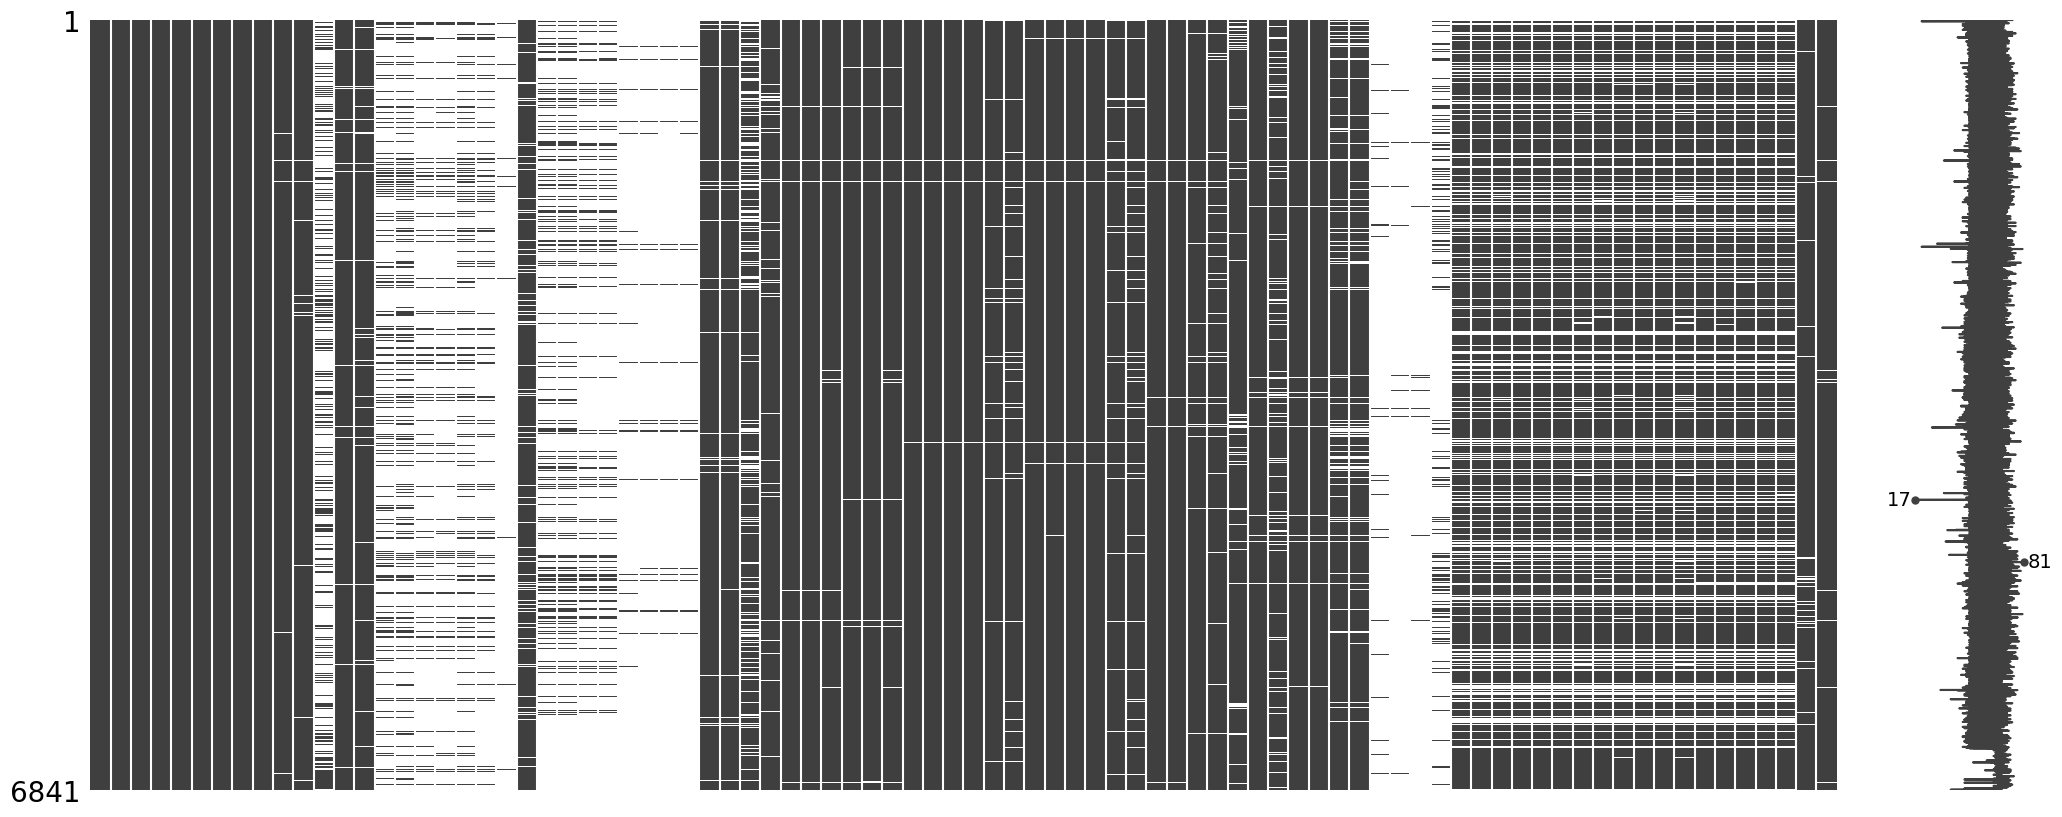

In [87]:
msno.matrix(data)

<Axes: >

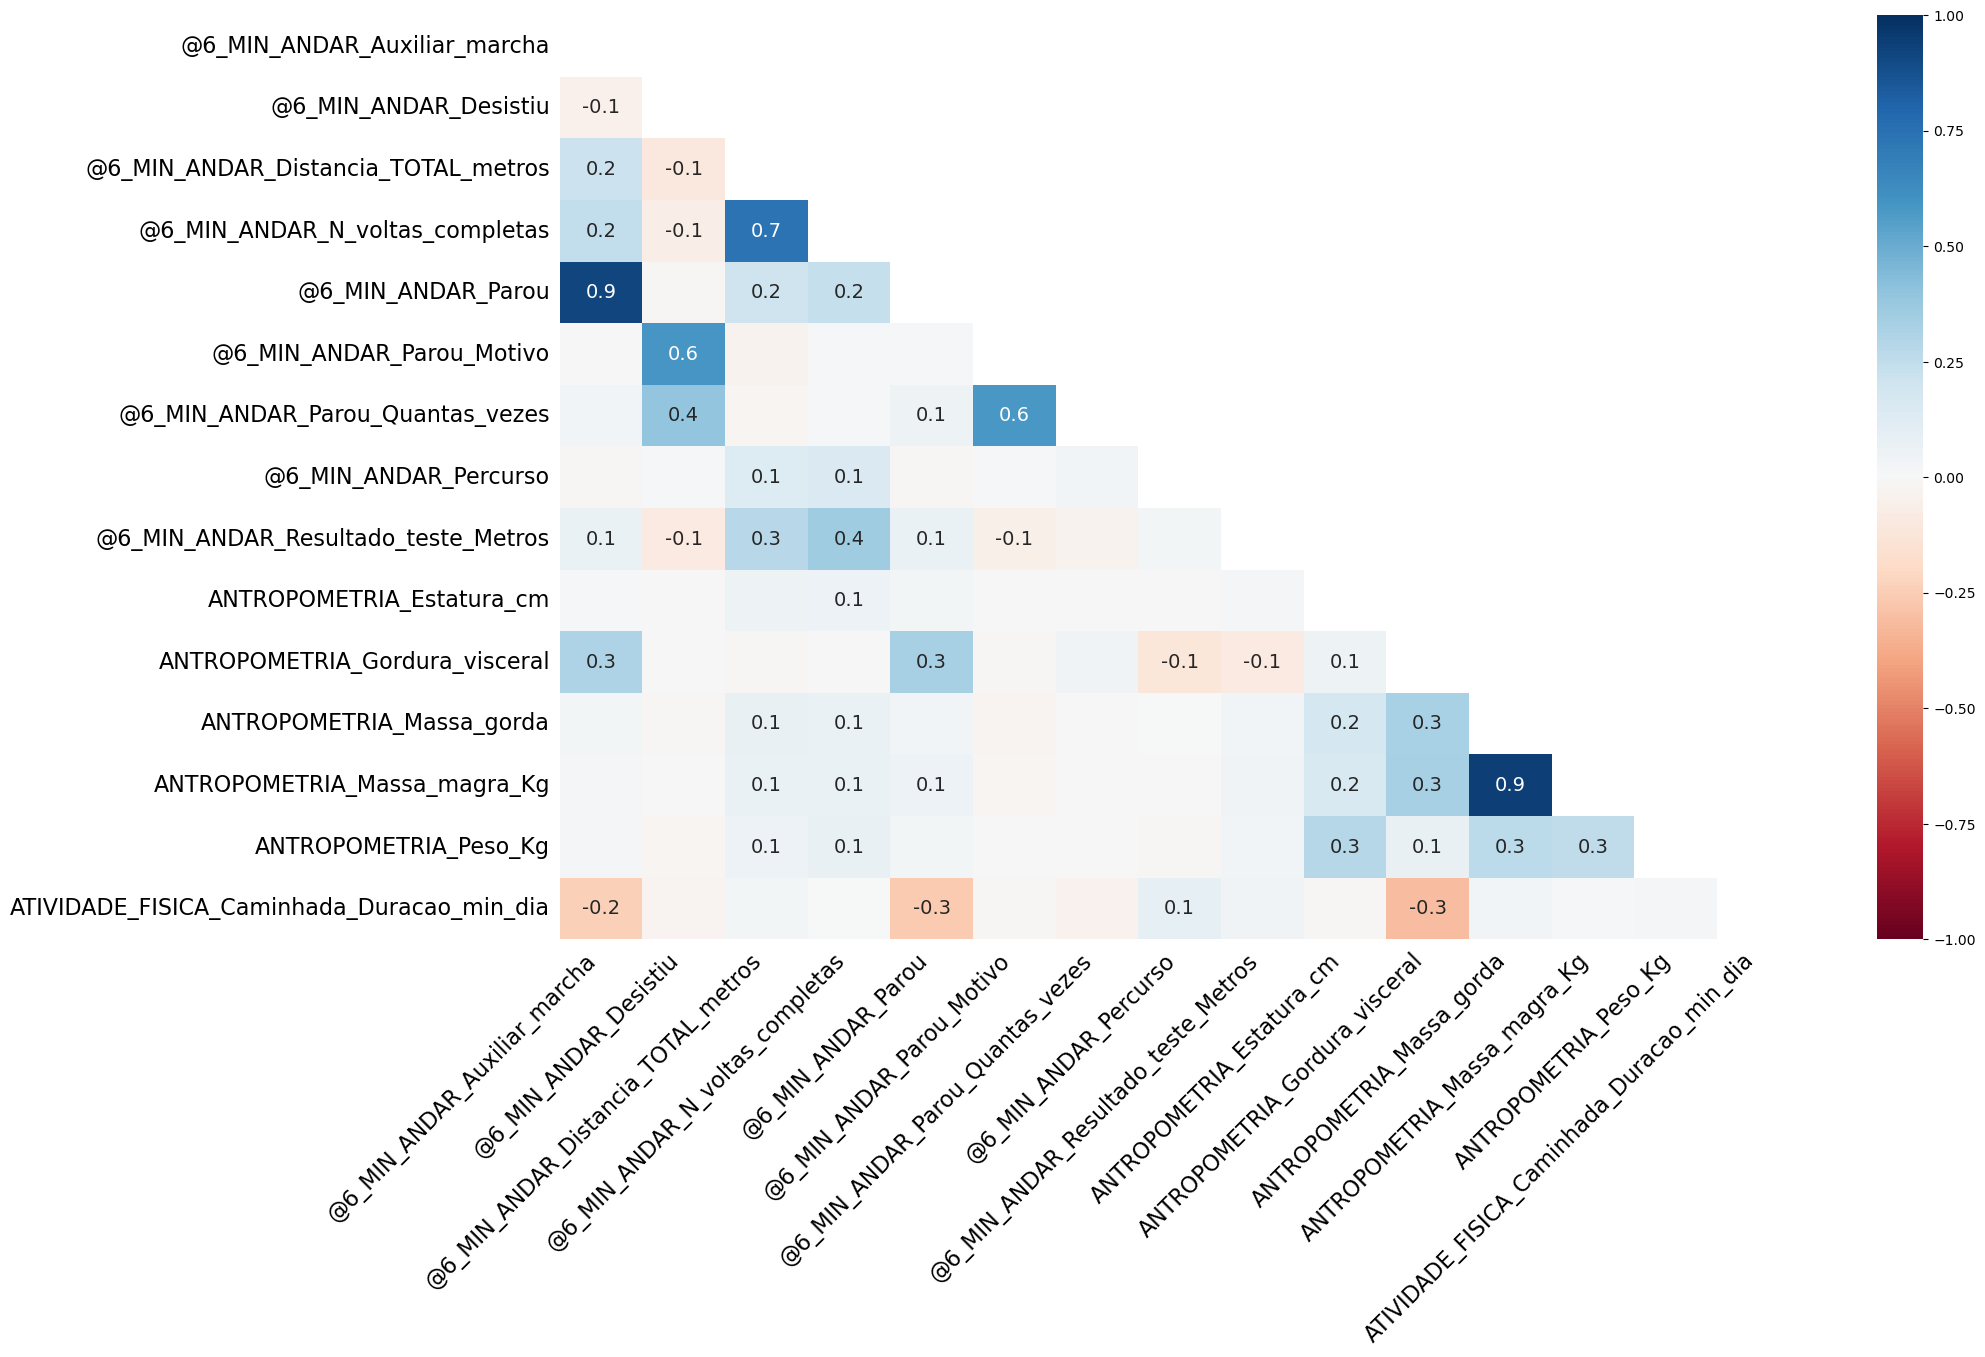

In [88]:
subset = data.columns[data.isnull().sum() > 0].sort_values(ascending=True)[:15] 
msno.heatmap(data[subset])

## Treat null values

In [89]:
pd.set_option('display.max_columns', None)
pd.set_option("display.max_rows", None)   
(data.isna().sum()).to_frame(name='null count').T

,ID_Aluno,Momento,Local_de_Avaliacao,Data_avaliacao,Data_nascimento,Age,Genero,Modalidade,Freq_semanal,ANTROPOMETRIA_Estatura_cm,ANTROPOMETRIA_Peso_Kg,Escolaridade,Quedas_ultimos_12meses,Quedas_12meses_Quantas,Quedas_12meses_Situacao,Quedas_12meses_Lesao_Sim_Nao,Quedas_12meses_Lesao_Tipo,Quedas_12meses_Lesao_Local,Quedas_12meses_Assistencia_hospitalar_Sim_Não,Quedas_12meses_Hospitalizado_Sim_Não,Quedas_12meses_Hospitalizado_Dias,Quedas_12meses_Medo_cair_Sim_Não,ATIVIDADE_FISICA_Geral_Sim_Não,ATIVIDADE_FISICA_Caminhada_Frequência_Dias_semana,ATIVIDADE_FISICA_Caminhada_Duracao_min_dia,ATIVIDADE_FISICA_Caminhada_Intensidade,ATIVIDADE_FISICA_Outras_AF_Qual,ATIVIDADE_FISICA_Outras_AF_Frequencia_Dias_semana,ATIVIDADE_FISICA_Outras_AF_Duracao_min_dia,ATIVIDADE_FISICA_Outras_AF_Intensidade,ANTROPOMETRIA_Massa_gorda,ANTROPOMETRIA_Massa_magra_Kg,ANTROPOMETRIA_Gordura_visceral,HANDGRIP_Mao_DOMINANTE,HANDGRIP_DIREITA_tentaiva1,HANDGRIP_DIREITA_tentativa2,HANDGRIP_DIREITA_tentativa_3,HANDGRIP_ESQUERDA_tentativa1,HANDGRIP_ESQUERDA_tentativa2,HANDGRIP_ESQUERDA_tentativa3,TIMED_UP_AND_GO_Simples_tentativa1,TIMED_UP_AND_GO_Simples_tentativa2,Best_TIMED_UP_AND_GO_Simples,Percentil_TIMED_UP_AND_GO_Simples,TIMED_UP_AND_GO_Simples_Apoio_mãos,TIMED_UP_AND_GO_Simples_Auxiliar_marcha,TIMED_UP_AND_GO_Dupla_tarefa_tentativa1,TIMED_UP_AND_GO_Dupla_tarefa_tentativa2,Best_TIMED_UP_AND_GO_Dupla_tarefa,Percentil_TIMED_UP_AND_GO_Dupla_tarefa,TIMED_UP_AND_GO_Dupla_tarefa_Apoio_maos,TIMED_UP_AND_GO_Dupla_tarefa_Auxiliar_marcha,SIT_TO_STAND_Repetiçoes,Percentil_SIT_TO_STAND_Repetiçoes,SIT_TO_STAND_Apoio_maos,SIT_TO_STAND_Auxiliar_marcha,@6_MIN_ANDAR_Percurso,@6_MIN_ANDAR_N_voltas_completas,@6_MIN_ANDAR_Resultado_teste_Metros,@6_MIN_ANDAR_Distancia_TOTAL_metros,Percentil_@6_MIN_ANDAR_Distancia_TOTAL_metros,@6_MIN_ANDAR_Auxiliar_marcha,@6_MIN_ANDAR_Parou,@6_MIN_ANDAR_Parou_Quantas_vezes,@6_MIN_ANDAR_Parou_Motivo,@6_MIN_ANDAR_Desistiu,MMSE_EDUCAÇAO,MMSE_ORIENTACAO_TEMPORAL,MMSE_ORIENTACAO_ESPACIAL,MMSE_RETENCAO,MMSE_ATENCAO_CALCULO,MMSE_EVOCACAO_1,MMSE_LINGUAGEM_A_NOMEACAO,MMSE_LINGUAGEM_B_REPETICAO,MMSE_LINGUAGEM_C_COMANDO,MMSE_LINGUAGEM_D_LEITURA,MMSE_LINGUAGEM_E_FRASE_ESCRITA,MMSE_COPIA_DESENHO_1,MMSE_Total,EQ5D5L_MOBILIDADE,EQ5D5L_CUIDADOS_PESSOAIS,EQ5D5L_ATIVIDADES_HABITUAIS,EQ5D5L_DOR_MAL_ESTAR,EQ5D5L_ANSIEDADE_DEPRESSAO,EQ5D5L_A_sua_saude_hoje_0_100,HANDGRIP_DIREITA_tentativa_2
null count,0,0,0,0,1,0,0,2,2,68,68,4971,136,251,5394,5200,6040,6085,5574,5927,6755,567,5433,5430,6045,6037,6612,6637,6636,6631,223,250,1651,312,56,58,109,65,67,115,35,42,35,35,119,270,43,53,43,43,206,367,49,49,145,344,398,79,571,101,101,650,627,6659,6762,6783,5674,1485,1484,1508,1489,1496,1486,1529,1492,1514,1508,1488,1616,1487,1486,1488,1486,1491,181,109


## Forward & backward fill, and implicit relations

In [90]:
colls_to_ffill_bfill = ["Age", "Modalidade", "Freq_semanal", "ANTROPOMETRIA_Estatura_cm", "ANTROPOMETRIA_Peso_Kg",
                        "Escolaridade", "MMSE_EDUCAÇAO", "Data_nascimento",
                        "Quedas_12meses_Medo_cair_Sim_Não",
                        "ATIVIDADE_FISICA_Geral_Sim_Não", "ATIVIDADE_FISICA_Caminhada_Frequência_Dias_semana",
                        "ATIVIDADE_FISICA_Caminhada_Duracao_min_dia", "ATIVIDADE_FISICA_Caminhada_Intensidade",
                        "ATIVIDADE_FISICA_Outras_AF_Frequencia_Dias_semana", "ATIVIDADE_FISICA_Outras_AF_Duracao_min_dia",
                        "ATIVIDADE_FISICA_Outras_AF_Intensidade", "ANTROPOMETRIA_Massa_gorda", "ANTROPOMETRIA_Massa_magra_Kg", 
                        "ANTROPOMETRIA_Gordura_visceral", "HANDGRIP_Mao_DOMINANTE", 
                        ]

In [91]:
((data.isna()).sum()).to_frame(name='null count').T

,ID_Aluno,Momento,Local_de_Avaliacao,Data_avaliacao,Data_nascimento,Age,Genero,Modalidade,Freq_semanal,ANTROPOMETRIA_Estatura_cm,ANTROPOMETRIA_Peso_Kg,Escolaridade,Quedas_ultimos_12meses,Quedas_12meses_Quantas,Quedas_12meses_Situacao,Quedas_12meses_Lesao_Sim_Nao,Quedas_12meses_Lesao_Tipo,Quedas_12meses_Lesao_Local,Quedas_12meses_Assistencia_hospitalar_Sim_Não,Quedas_12meses_Hospitalizado_Sim_Não,Quedas_12meses_Hospitalizado_Dias,Quedas_12meses_Medo_cair_Sim_Não,ATIVIDADE_FISICA_Geral_Sim_Não,ATIVIDADE_FISICA_Caminhada_Frequência_Dias_semana,ATIVIDADE_FISICA_Caminhada_Duracao_min_dia,ATIVIDADE_FISICA_Caminhada_Intensidade,ATIVIDADE_FISICA_Outras_AF_Qual,ATIVIDADE_FISICA_Outras_AF_Frequencia_Dias_semana,ATIVIDADE_FISICA_Outras_AF_Duracao_min_dia,ATIVIDADE_FISICA_Outras_AF_Intensidade,ANTROPOMETRIA_Massa_gorda,ANTROPOMETRIA_Massa_magra_Kg,ANTROPOMETRIA_Gordura_visceral,HANDGRIP_Mao_DOMINANTE,HANDGRIP_DIREITA_tentaiva1,HANDGRIP_DIREITA_tentativa2,HANDGRIP_DIREITA_tentativa_3,HANDGRIP_ESQUERDA_tentativa1,HANDGRIP_ESQUERDA_tentativa2,HANDGRIP_ESQUERDA_tentativa3,TIMED_UP_AND_GO_Simples_tentativa1,TIMED_UP_AND_GO_Simples_tentativa2,Best_TIMED_UP_AND_GO_Simples,Percentil_TIMED_UP_AND_GO_Simples,TIMED_UP_AND_GO_Simples_Apoio_mãos,TIMED_UP_AND_GO_Simples_Auxiliar_marcha,TIMED_UP_AND_GO_Dupla_tarefa_tentativa1,TIMED_UP_AND_GO_Dupla_tarefa_tentativa2,Best_TIMED_UP_AND_GO_Dupla_tarefa,Percentil_TIMED_UP_AND_GO_Dupla_tarefa,TIMED_UP_AND_GO_Dupla_tarefa_Apoio_maos,TIMED_UP_AND_GO_Dupla_tarefa_Auxiliar_marcha,SIT_TO_STAND_Repetiçoes,Percentil_SIT_TO_STAND_Repetiçoes,SIT_TO_STAND_Apoio_maos,SIT_TO_STAND_Auxiliar_marcha,@6_MIN_ANDAR_Percurso,@6_MIN_ANDAR_N_voltas_completas,@6_MIN_ANDAR_Resultado_teste_Metros,@6_MIN_ANDAR_Distancia_TOTAL_metros,Percentil_@6_MIN_ANDAR_Distancia_TOTAL_metros,@6_MIN_ANDAR_Auxiliar_marcha,@6_MIN_ANDAR_Parou,@6_MIN_ANDAR_Parou_Quantas_vezes,@6_MIN_ANDAR_Parou_Motivo,@6_MIN_ANDAR_Desistiu,MMSE_EDUCAÇAO,MMSE_ORIENTACAO_TEMPORAL,MMSE_ORIENTACAO_ESPACIAL,MMSE_RETENCAO,MMSE_ATENCAO_CALCULO,MMSE_EVOCACAO_1,MMSE_LINGUAGEM_A_NOMEACAO,MMSE_LINGUAGEM_B_REPETICAO,MMSE_LINGUAGEM_C_COMANDO,MMSE_LINGUAGEM_D_LEITURA,MMSE_LINGUAGEM_E_FRASE_ESCRITA,MMSE_COPIA_DESENHO_1,MMSE_Total,EQ5D5L_MOBILIDADE,EQ5D5L_CUIDADOS_PESSOAIS,EQ5D5L_ATIVIDADES_HABITUAIS,EQ5D5L_DOR_MAL_ESTAR,EQ5D5L_ANSIEDADE_DEPRESSAO,EQ5D5L_A_sua_saude_hoje_0_100,HANDGRIP_DIREITA_tentativa_2
null count,0,0,0,0,1,0,0,2,2,68,68,4971,136,251,5394,5200,6040,6085,5574,5927,6755,567,5433,5430,6045,6037,6612,6637,6636,6631,223,250,1651,312,56,58,109,65,67,115,35,42,35,35,119,270,43,53,43,43,206,367,49,49,145,344,398,79,571,101,101,650,627,6659,6762,6783,5674,1485,1484,1508,1489,1496,1486,1529,1492,1514,1508,1488,1616,1487,1486,1488,1486,1491,181,109


In [92]:

def handle_nulls(df):
    # Forward and backward fill
    for col in colls_to_ffill_bfill:
        df[col] = df.groupby("ID_Aluno")[col].transform(lambda x: x.ffill().bfill())

    # Age
    df = df[df['Age'].notna()] # 5 pessoas sem Age

    # Quedas_ultimos_12meses
    # nao ha pessoas que têm isto null e tenham valor em Quedas_12meses_Quantas
    df = df[df['Quedas_ultimos_12meses'].notna()] # 136 pessoas que nao sabem se deram quedas ou quantas quedas deram nos ultimos 12 meses nem sabem quantas nem nada sobre quedas

    # Se não teve quedas, "quantas quedas" foram 0
    df.loc[(df['Quedas_ultimos_12meses'] == 0) & (df['Quedas_12meses_Quantas'].isnull()), 'Quedas_12meses_Quantas'] = 0

    non_zero_median = int(df.loc[df['Quedas_12meses_Quantas'] != 0, 'Quedas_12meses_Quantas'].median())
    print("non_zero_median for Quedas_12meses_Quantas ==", non_zero_median)
    df.loc[(df['Quedas_ultimos_12meses'] != 0) & (df['Quedas_12meses_Quantas'].isnull()), 'Quedas_12meses_Quantas'] = non_zero_median
    df.loc[(df['Quedas_ultimos_12meses'] != 0) & (df['Quedas_12meses_Quantas'] == 0), 'Quedas_12meses_Quantas'] = non_zero_median

    # Se não teve quedas, não teve lesão
    df.loc[(df['Quedas_12meses_Quantas'] == 0) & (df['Quedas_12meses_Lesao_Sim_Nao'].isnull()), 'Quedas_12meses_Lesao_Sim_Nao'] = 0

    # Se não teve quedas, não teve situação de queda
    df.loc[(df['Quedas_ultimos_12meses'] == 0) & (df['Quedas_12meses_Situacao'].isnull()), 'Quedas_12meses_Situacao'] = ""

    # Se teve lesão, marcar que teve lesão
    df.loc[((df['Quedas_12meses_Lesao_Local'].notnull()) | (df['Quedas_12meses_Lesao_Tipo'].notnull())) & (df['Quedas_12meses_Lesao_Sim_Nao'].isnull()), 'Quedas_12meses_Lesao_Sim_Nao'] = 1
    df.loc[(df['Quedas_12meses_Lesao_Local'].isnull()) & (df['Quedas_12meses_Lesao_Tipo'].isnull()) & (df['Quedas_12meses_Lesao_Sim_Nao'].isnull()), 'Quedas_12meses_Lesao_Sim_Nao'] = 0

    # Se não teve lesão, não teve tipo nem local de lesão
    df.loc[(df['Quedas_12meses_Lesao_Sim_Nao'] == 0) & (df['Quedas_12meses_Lesao_Tipo'].isnull()), 'Quedas_12meses_Lesao_Tipo'] = ""
    df.loc[(df['Quedas_12meses_Lesao_Sim_Nao'] == 0) & (df['Quedas_12meses_Lesao_Local'].isnull()), 'Quedas_12meses_Lesao_Local'] = ""


    # Quedas_12meses_Assistencia_hospitalar_Sim_Não
    #df.loc[(df['Quedas_ultimos_12meses'] == 0) & (df['Quedas_12meses_Assistencia_hospitalar_Sim_Não'].isnull()), 'Quedas_12meses_Assistencia_hospitalar_Sim_Não'] = 0
    #df.loc[(df['Quedas_12meses_Quantas'] == 0) & (df['Quedas_12meses_Assistencia_hospitalar_Sim_Não'].isnull()), 'Quedas_12meses_Assistencia_hospitalar_Sim_Não'] = 0
    df.loc[(df['Quedas_12meses_Lesao_Sim_Nao'] == 0), 'Quedas_12meses_Assistencia_hospitalar_Sim_Não'] = 0

    # Se não teve assistência hospitalar, não teve hospitalização
    df.loc[(df['Quedas_12meses_Assistencia_hospitalar_Sim_Não'] == 0), 'Quedas_12meses_Hospitalizado_Sim_Não'] = 0

    # Se não teve hospitalização, não teve dias de hospitalização
    df.loc[(df['Quedas_12meses_Hospitalizado_Sim_Não'] == 0), 'Quedas_12meses_Hospitalizado_Dias'] = 0
    df.loc[(df['Quedas_12meses_Hospitalizado_Dias'] == 0), 'Quedas_12meses_Hospitalizado_Sim_Não'] = 0


    non_zero_median2 = int(df.loc[df['Quedas_12meses_Hospitalizado_Dias'] != 0, 'Quedas_12meses_Hospitalizado_Dias'].median())
    print("non_zero_median for Quedas_12meses_Hospitalizado_Dias ==", non_zero_median2)
    df.loc[(df['Quedas_12meses_Hospitalizado_Sim_Não'] != 0) & (df['Quedas_12meses_Hospitalizado_Dias'] == 0), 'Quedas_12meses_Hospitalizado_Dias'] = non_zero_median2
    df.loc[(df['Quedas_12meses_Hospitalizado_Sim_Não'] != 0) & (df['Quedas_12meses_Hospitalizado_Dias'].isnull()), 'Quedas_12meses_Hospitalizado_Dias'] = non_zero_median2


    # @6_MIN_ANDAR_Parou_Quantas_vezes
    df.loc[(df['@6_MIN_ANDAR_Parou'] == 0) & (df['@6_MIN_ANDAR_Parou_Quantas_vezes'].isnull()), '@6_MIN_ANDAR_Parou_Quantas_vezes'] = 0
    df.loc[(df['@6_MIN_ANDAR_Parou_Quantas_vezes'] == 0) & (df['@6_MIN_ANDAR_Parou'].isnull()), '@6_MIN_ANDAR_Parou'] = 0

    non_zero_median1 = int(df.loc[df['@6_MIN_ANDAR_Parou_Quantas_vezes'] != 0, '@6_MIN_ANDAR_Parou_Quantas_vezes'].median())
    print("non_zero_median for @6_MIN_ANDAR_Parou_Quantas_vezes ==", non_zero_median1)
    df.loc[(df['@6_MIN_ANDAR_Parou'] == 1) & (df['@6_MIN_ANDAR_Parou_Quantas_vezes'].isnull()), '@6_MIN_ANDAR_Parou_Quantas_vezes'] = non_zero_median1

    df.loc[(df['@6_MIN_ANDAR_Parou_Motivo'].notnull()) & (df['@6_MIN_ANDAR_Parou'].isnull()), '@6_MIN_ANDAR_Parou'] = 1
    df.loc[(df['@6_MIN_ANDAR_Desistiu'].notnull()) & (df['@6_MIN_ANDAR_Parou'].isnull()), '@6_MIN_ANDAR_Parou'] = 1

    df.loc[(df['@6_MIN_ANDAR_Parou_Motivo'].notnull()) & (df['@6_MIN_ANDAR_Parou'] == 0), '@6_MIN_ANDAR_Parou'] = 1
    df.loc[(df['@6_MIN_ANDAR_Desistiu'].notnull()) & (df['@6_MIN_ANDAR_Parou'] == 0), '@6_MIN_ANDAR_Parou'] = 1

    df.loc[(df['@6_MIN_ANDAR_Parou_Motivo'].notnull()) & (df['@6_MIN_ANDAR_Parou_Quantas_vezes'].isnull()), '@6_MIN_ANDAR_Parou_Quantas_vezes'] = non_zero_median1
    df.loc[(df['@6_MIN_ANDAR_Desistiu'].notnull()) & (df['@6_MIN_ANDAR_Parou_Quantas_vezes'].isnull()), '@6_MIN_ANDAR_Parou_Quantas_vezes'] = non_zero_median1

    df.loc[(df['@6_MIN_ANDAR_Parou_Motivo'].notnull()) & (df['@6_MIN_ANDAR_Parou_Quantas_vezes'] == 0), '@6_MIN_ANDAR_Parou_Quantas_vezes'] = non_zero_median1
    df.loc[(df['@6_MIN_ANDAR_Desistiu'].notnull()) & (df['@6_MIN_ANDAR_Parou_Quantas_vezes'] == 0), '@6_MIN_ANDAR_Parou_Quantas_vezes'] = non_zero_median1


    # 6 min andar parou motivo / desistiu
    df.loc[(df['@6_MIN_ANDAR_Desistiu'].notnull()) & (df['@6_MIN_ANDAR_Parou_Motivo'].isnull()), '@6_MIN_ANDAR_Parou_Motivo'] = df['@6_MIN_ANDAR_Desistiu']
    df.loc[(df['@6_MIN_ANDAR_Parou_Motivo'].notnull()) & (df['@6_MIN_ANDAR_Desistiu'].isnull()), '@6_MIN_ANDAR_Desistiu'] = df['@6_MIN_ANDAR_Parou_Motivo']

    df.loc[(df['@6_MIN_ANDAR_Parou'] == 0) & (df['@6_MIN_ANDAR_Parou_Motivo'].isnull()), '@6_MIN_ANDAR_Parou_Motivo'] = ""
    df.loc[(df['@6_MIN_ANDAR_Parou'] == 0) & (df['@6_MIN_ANDAR_Desistiu'].isnull()), '@6_MIN_ANDAR_Desistiu'] = ""

    # Escolaridade | MMSE_EDUCAÇAO
    df.loc[(df['Escolaridade'].notnull()) & (df['MMSE_EDUCAÇAO'].isnull()), 'MMSE_EDUCAÇAO'] = df["Escolaridade"]
    df.loc[(df['MMSE_EDUCAÇAO'].notnull()) & (df['Escolaridade'].isnull()), 'Escolaridade'] = df["MMSE_EDUCAÇAO"]

    # @6_MIN_ANDAR_Parou	@6_MIN_ANDAR_Parou_Quantas_vezes

    ############# IMPORTANTE ######################
    # Quedas_12meses_Medo_cair_Sim_Não 
    # cerca de 500 que sao null, nao sabem se têm medo de cair.
    # pôr as que nao cairam como que têm medo, e as que nao cairam como nao tendo medo.
    df.loc[(df['Quedas_ultimos_12meses'] == 0) & (df['Quedas_12meses_Medo_cair_Sim_Não'].isnull()), 'Quedas_12meses_Medo_cair_Sim_Não'] = 0
    df.loc[(df['Quedas_ultimos_12meses'] == 1) & (df['Quedas_12meses_Medo_cair_Sim_Não'].isnull()), 'Quedas_12meses_Medo_cair_Sim_Não'] = 1


    # Mediana: [Modalidade, Freq_semanal, ANTROPOMETRIA_Estatura_cm, ANTROPOMETRIA_Peso_Kg, Escolaridade,



    return df

data = handle_nulls(data)

non_zero_median for Quedas_12meses_Quantas == 1
non_zero_median for Quedas_12meses_Hospitalizado_Dias == 5
non_zero_median for @6_MIN_ANDAR_Parou_Quantas_vezes == 1


In [93]:
data['Quedas_ultimos_12meses'].value_counts()

Quedas_ultimos_12meses
0.0    5141
1.0    1564
Name: count, dtype: int64

In [94]:
((data.isna()).sum()).to_frame(name='null count').T

,ID_Aluno,Momento,Local_de_Avaliacao,Data_avaliacao,Data_nascimento,Age,Genero,Modalidade,Freq_semanal,ANTROPOMETRIA_Estatura_cm,ANTROPOMETRIA_Peso_Kg,Escolaridade,Quedas_ultimos_12meses,Quedas_12meses_Quantas,Quedas_12meses_Situacao,Quedas_12meses_Lesao_Sim_Nao,Quedas_12meses_Lesao_Tipo,Quedas_12meses_Lesao_Local,Quedas_12meses_Assistencia_hospitalar_Sim_Não,Quedas_12meses_Hospitalizado_Sim_Não,Quedas_12meses_Hospitalizado_Dias,Quedas_12meses_Medo_cair_Sim_Não,ATIVIDADE_FISICA_Geral_Sim_Não,ATIVIDADE_FISICA_Caminhada_Frequência_Dias_semana,ATIVIDADE_FISICA_Caminhada_Duracao_min_dia,ATIVIDADE_FISICA_Caminhada_Intensidade,ATIVIDADE_FISICA_Outras_AF_Qual,ATIVIDADE_FISICA_Outras_AF_Frequencia_Dias_semana,ATIVIDADE_FISICA_Outras_AF_Duracao_min_dia,ATIVIDADE_FISICA_Outras_AF_Intensidade,ANTROPOMETRIA_Massa_gorda,ANTROPOMETRIA_Massa_magra_Kg,ANTROPOMETRIA_Gordura_visceral,HANDGRIP_Mao_DOMINANTE,HANDGRIP_DIREITA_tentaiva1,HANDGRIP_DIREITA_tentativa2,HANDGRIP_DIREITA_tentativa_3,HANDGRIP_ESQUERDA_tentativa1,HANDGRIP_ESQUERDA_tentativa2,HANDGRIP_ESQUERDA_tentativa3,TIMED_UP_AND_GO_Simples_tentativa1,TIMED_UP_AND_GO_Simples_tentativa2,Best_TIMED_UP_AND_GO_Simples,Percentil_TIMED_UP_AND_GO_Simples,TIMED_UP_AND_GO_Simples_Apoio_mãos,TIMED_UP_AND_GO_Simples_Auxiliar_marcha,TIMED_UP_AND_GO_Dupla_tarefa_tentativa1,TIMED_UP_AND_GO_Dupla_tarefa_tentativa2,Best_TIMED_UP_AND_GO_Dupla_tarefa,Percentil_TIMED_UP_AND_GO_Dupla_tarefa,TIMED_UP_AND_GO_Dupla_tarefa_Apoio_maos,TIMED_UP_AND_GO_Dupla_tarefa_Auxiliar_marcha,SIT_TO_STAND_Repetiçoes,Percentil_SIT_TO_STAND_Repetiçoes,SIT_TO_STAND_Apoio_maos,SIT_TO_STAND_Auxiliar_marcha,@6_MIN_ANDAR_Percurso,@6_MIN_ANDAR_N_voltas_completas,@6_MIN_ANDAR_Resultado_teste_Metros,@6_MIN_ANDAR_Distancia_TOTAL_metros,Percentil_@6_MIN_ANDAR_Distancia_TOTAL_metros,@6_MIN_ANDAR_Auxiliar_marcha,@6_MIN_ANDAR_Parou,@6_MIN_ANDAR_Parou_Quantas_vezes,@6_MIN_ANDAR_Parou_Motivo,@6_MIN_ANDAR_Desistiu,MMSE_EDUCAÇAO,MMSE_ORIENTACAO_TEMPORAL,MMSE_ORIENTACAO_ESPACIAL,MMSE_RETENCAO,MMSE_ATENCAO_CALCULO,MMSE_EVOCACAO_1,MMSE_LINGUAGEM_A_NOMEACAO,MMSE_LINGUAGEM_B_REPETICAO,MMSE_LINGUAGEM_C_COMANDO,MMSE_LINGUAGEM_D_LEITURA,MMSE_LINGUAGEM_E_FRASE_ESCRITA,MMSE_COPIA_DESENHO_1,MMSE_Total,EQ5D5L_MOBILIDADE,EQ5D5L_CUIDADOS_PESSOAIS,EQ5D5L_ATIVIDADES_HABITUAIS,EQ5D5L_DOR_MAL_ESTAR,EQ5D5L_ANSIEDADE_DEPRESSAO,EQ5D5L_A_sua_saude_hoje_0_100,HANDGRIP_DIREITA_tentativa_2
null count,0,0,0,0,0,0,0,2,2,32,10,889,0,0,119,0,57,102,40,46,0,0,2602,2596,4335,4311,6476,6096,6098,6082,35,37,242,30,49,51,102,59,61,109,31,38,31,31,114,265,39,49,39,39,199,360,44,44,139,337,361,77,555,99,99,645,615,615,633,633,889,1450,1449,1474,1454,1461,1452,1494,1458,1480,1474,1454,1580,1453,1452,1454,1451,1456,164,102


In [95]:
data[data['MMSE_Total'].isnull()]['Momento'].value_counts()

Momento
2    1428
4      75
3      52
1      25
Name: count, dtype: int64

## Look again with missingno

<Axes: >

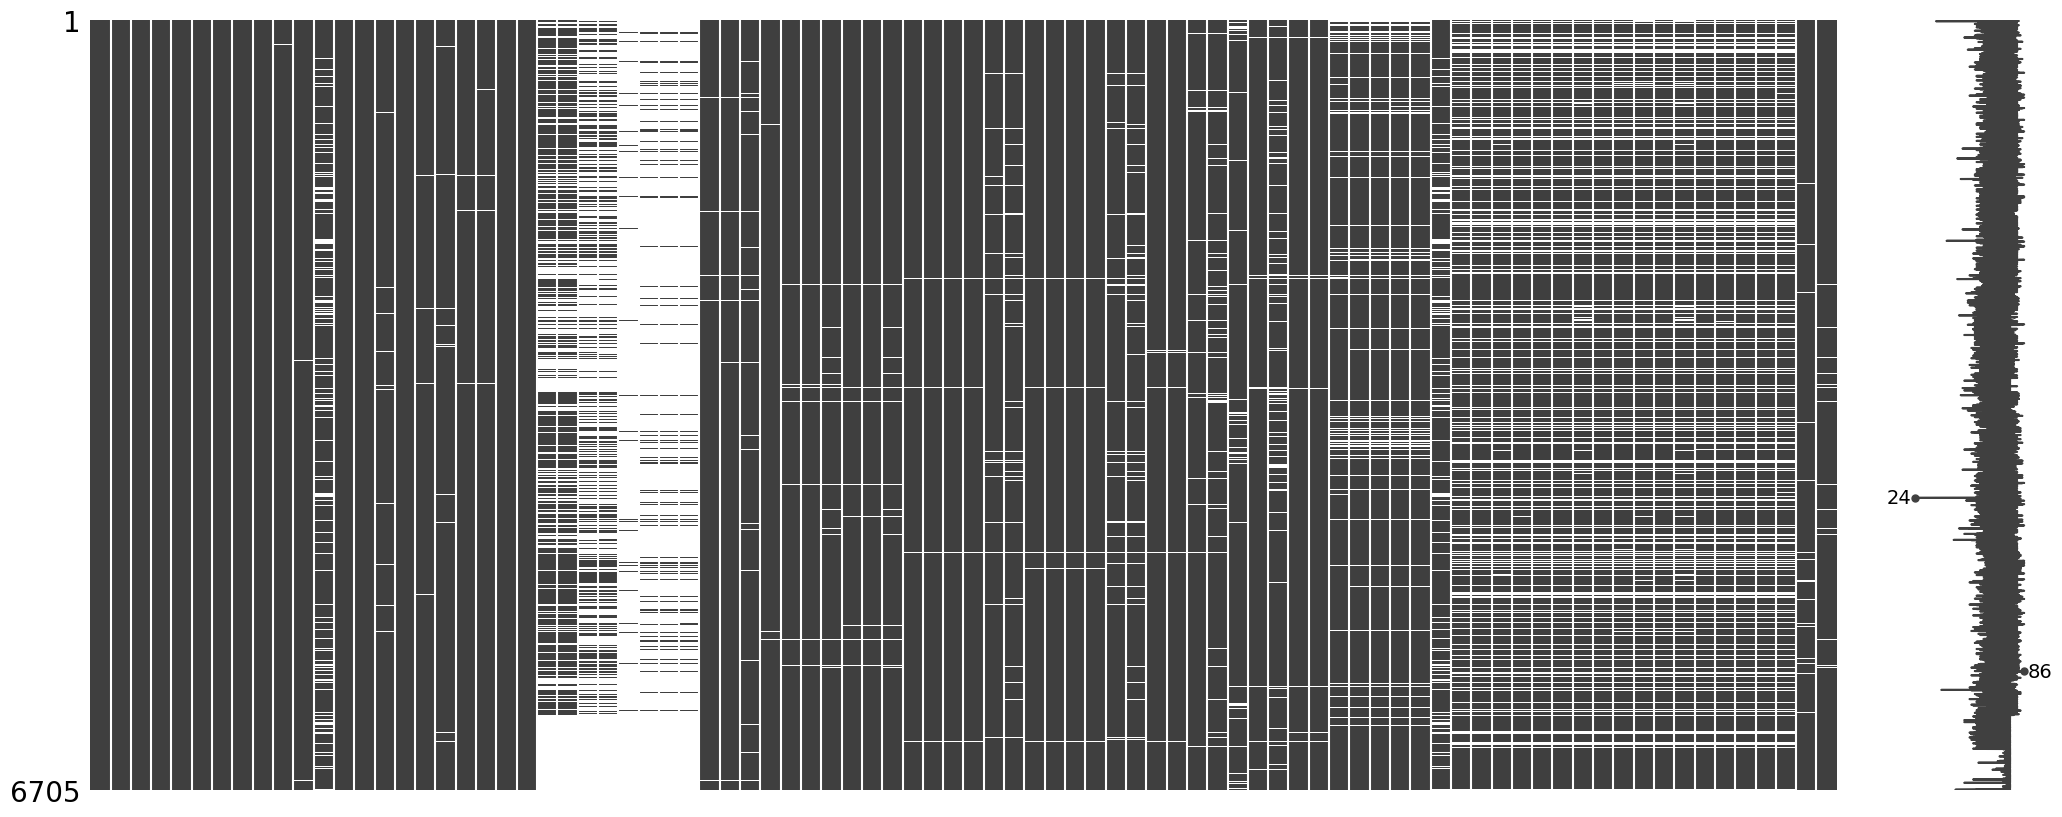

In [96]:
msno.matrix(data)

<Axes: >

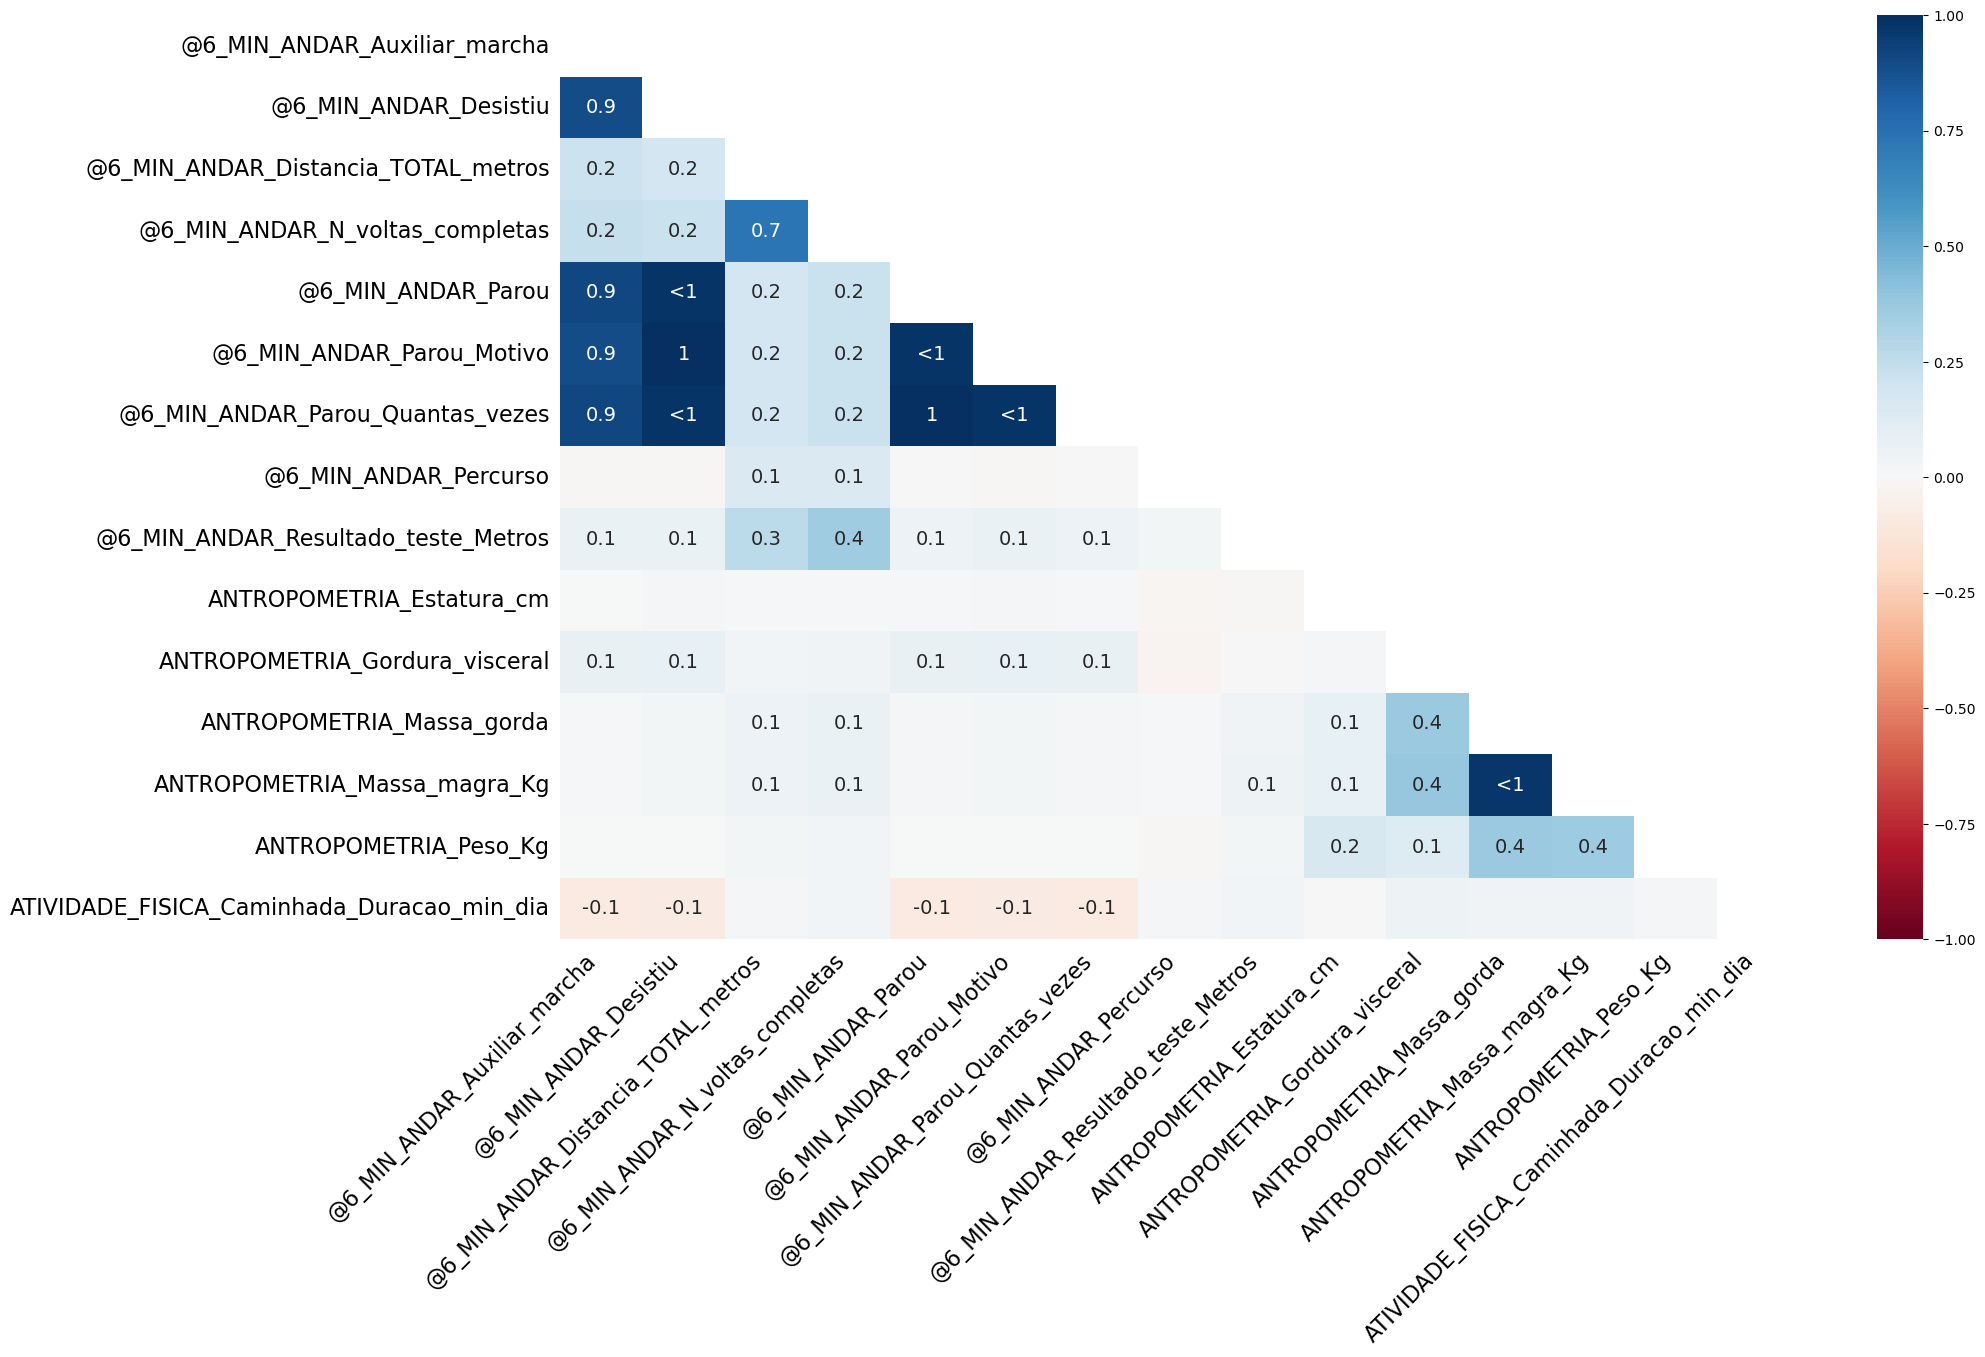

In [97]:
subset = data.columns[data.isnull().sum() > 0].sort_values(ascending=True)[:15]
msno.heatmap(data[subset])

## Percentage of missing values

In [98]:
missing_ratios = data.isna().mean()
missing_ratios.tail()

EQ5D5L_ATIVIDADES_HABITUAIS      0.216853
EQ5D5L_DOR_MAL_ESTAR             0.216406
EQ5D5L_ANSIEDADE_DEPRESSAO       0.217151
EQ5D5L_A_sua_saude_hoje_0_100    0.024459
HANDGRIP_DIREITA_tentativa_2     0.015213
dtype: float64

In [99]:
treshold1 = 0.05
treshold2 = 0.20
treshold3 = 0.40

pval_thresh = 0.1

missing_cols_0_5 = missing_ratios[missing_ratios < treshold1].index.tolist()
missing_cols_5_20 = missing_ratios[(missing_ratios < treshold2) & (missing_ratios > treshold1)].index.tolist()
missing_cols_20_40 = missing_ratios[(missing_ratios < treshold3) & (missing_ratios > treshold2)].index.tolist()
missing_cols_40_100 = missing_ratios[missing_ratios > treshold3].index.tolist()

print("missing_cols_40_100:", missing_cols_40_100)
print("missing_cols_20_40:", missing_cols_20_40)
print("missing_cols_5_20", missing_cols_5_20)

missing_cols_40_100: ['ATIVIDADE_FISICA_Caminhada_Duracao_min_dia', 'ATIVIDADE_FISICA_Caminhada_Intensidade', 'ATIVIDADE_FISICA_Outras_AF_Qual', 'ATIVIDADE_FISICA_Outras_AF_Frequencia_Dias_semana', 'ATIVIDADE_FISICA_Outras_AF_Duracao_min_dia', 'ATIVIDADE_FISICA_Outras_AF_Intensidade']
missing_cols_20_40: ['ATIVIDADE_FISICA_Geral_Sim_Não', 'ATIVIDADE_FISICA_Caminhada_Frequência_Dias_semana', 'MMSE_ORIENTACAO_TEMPORAL', 'MMSE_ORIENTACAO_ESPACIAL', 'MMSE_RETENCAO', 'MMSE_ATENCAO_CALCULO', 'MMSE_EVOCACAO_1', 'MMSE_LINGUAGEM_A_NOMEACAO', 'MMSE_LINGUAGEM_B_REPETICAO', 'MMSE_LINGUAGEM_C_COMANDO', 'MMSE_LINGUAGEM_D_LEITURA', 'MMSE_LINGUAGEM_E_FRASE_ESCRITA', 'MMSE_COPIA_DESENHO_1', 'MMSE_Total', 'EQ5D5L_MOBILIDADE', 'EQ5D5L_CUIDADOS_PESSOAIS', 'EQ5D5L_ATIVIDADES_HABITUAIS', 'EQ5D5L_DOR_MAL_ESTAR', 'EQ5D5L_ANSIEDADE_DEPRESSAO']
missing_cols_5_20 ['Escolaridade', 'TIMED_UP_AND_GO_Dupla_tarefa_Auxiliar_marcha', 'SIT_TO_STAND_Auxiliar_marcha', '@6_MIN_ANDAR_Percurso', '@6_MIN_ANDAR_Resultado_teste

In [100]:
print(missing_ratios["ATIVIDADE_FISICA_Geral_Sim_Não"])
print(missing_ratios["ATIVIDADE_FISICA_Caminhada_Frequência_Dias_semana"])

0.38806860551826994
0.3871737509321402


## F-scores and p_values

In [101]:
# target variable to f_classif Quedas_ultimos_12meses
X = data.drop(columns=["Quedas_ultimos_12meses"])
y = data["Quedas_ultimos_12meses"]

### 20%-40% missing values variables

In [102]:
missing_cols_20_40

['ATIVIDADE_FISICA_Geral_Sim_Não',
 'ATIVIDADE_FISICA_Caminhada_Frequência_Dias_semana',
 'MMSE_ORIENTACAO_TEMPORAL',
 'MMSE_ORIENTACAO_ESPACIAL',
 'MMSE_RETENCAO',
 'MMSE_ATENCAO_CALCULO',
 'MMSE_EVOCACAO_1',
 'MMSE_LINGUAGEM_A_NOMEACAO',
 'MMSE_LINGUAGEM_B_REPETICAO',
 'MMSE_LINGUAGEM_C_COMANDO',
 'MMSE_LINGUAGEM_D_LEITURA',
 'MMSE_LINGUAGEM_E_FRASE_ESCRITA',
 'MMSE_COPIA_DESENHO_1',
 'MMSE_Total',
 'EQ5D5L_MOBILIDADE',
 'EQ5D5L_CUIDADOS_PESSOAIS',
 'EQ5D5L_ATIVIDADES_HABITUAIS',
 'EQ5D5L_DOR_MAL_ESTAR',
 'EQ5D5L_ANSIEDADE_DEPRESSAO']

In [103]:
results = []

for col in missing_cols_20_40:
    # Drop rows where either X[col] or y is null
    valid_idx = X[col].notnull() & y.notnull()
    X_valid = X.loc[valid_idx, [col]]
    y_valid = y.loc[valid_idx]

    
    f_score, p_val = f_classif(X_valid, y_valid)
    
    results.append({'Feature': col, 'f_score': f_score[0], 'p_value': p_val[0]})

# Convert results to DataFrame
results_df = pd.DataFrame(results)
results_df.sort_values('p_value').head(20)


,Feature,f_score,p_value
14,EQ5D5L_MOBILIDADE,219.418599,1.150364e-48
16,EQ5D5L_ATIVIDADES_HABITUAIS,123.966539,1.781834e-28
15,EQ5D5L_CUIDADOS_PESSOAIS,91.053142,2.083966e-21
17,EQ5D5L_DOR_MAL_ESTAR,90.796366,2.367323e-21
18,EQ5D5L_ANSIEDADE_DEPRESSAO,66.625580,4.074489e-16
0,ATIVIDADE_FISICA_Geral_Sim_Não,32.230615,1.463838e-08
13,MMSE_Total,24.598031,7.290512e-07
12,MMSE_COPIA_DESENHO_1,24.413693,8.012791e-07
5,MMSE_ATENCAO_CALCULO,21.171420,4.298681e-06
1,ATIVIDADE_FISICA_Caminhada_Frequência_Dias_semana,12.278538,4.630870e-04


In [104]:
features_high_p_value = results_df[results_df['p_value'] > pval_thresh]
features_high_p_value_list = features_high_p_value["Feature"].to_list()

print("❌ Features to delete (p ≥ {:.2f}):".format(pval_thresh), "\n", features_high_p_value_list)
features_high_p_value.head()

❌ Features to delete (p ≥ 0.10): 
 ['MMSE_RETENCAO', 'MMSE_EVOCACAO_1', 'MMSE_LINGUAGEM_A_NOMEACAO', 'MMSE_LINGUAGEM_B_REPETICAO', 'MMSE_LINGUAGEM_D_LEITURA']


,Feature,f_score,p_value
4,MMSE_RETENCAO,0.350712,0.553736
6,MMSE_EVOCACAO_1,1.558450,0.211948
7,MMSE_LINGUAGEM_A_NOMEACAO,0.415041,0.519450
8,MMSE_LINGUAGEM_B_REPETICAO,2.142655,0.143314
10,MMSE_LINGUAGEM_D_LEITURA,2.295077,0.129845


### 5%-20% missing values variables

In [105]:
missing_cols_5_20.remove("@6_MIN_ANDAR_Parou_Motivo")
missing_cols_5_20.remove("@6_MIN_ANDAR_Desistiu")
missing_cols_5_20

['Escolaridade',
 'TIMED_UP_AND_GO_Dupla_tarefa_Auxiliar_marcha',
 'SIT_TO_STAND_Auxiliar_marcha',
 '@6_MIN_ANDAR_Percurso',
 '@6_MIN_ANDAR_Resultado_teste_Metros',
 '@6_MIN_ANDAR_Auxiliar_marcha',
 '@6_MIN_ANDAR_Parou',
 '@6_MIN_ANDAR_Parou_Quantas_vezes',
 'MMSE_EDUCAÇAO']

In [106]:
results2 = []

for col in missing_cols_5_20:
    # Drop rows where either X[col] or y is null
    valid_idx = X[col].notnull() & y.notnull()
    X_valid = X.loc[valid_idx, [col]]
    y_valid = y.loc[valid_idx]

    
    f_score, p_val = f_classif(X_valid, y_valid)
    
    results2.append({'Feature': col, 'f_score': f_score[0], 'p_value': p_val[0]})

# Convert results to DataFrame
results2_df = pd.DataFrame(results2)
results2_df.sort_values('p_value').head(10)

,Feature,f_score,p_value
8,MMSE_EDUCAÇAO,35.069923,3.362771e-09
0,Escolaridade,28.811218,8.287906e-08
7,@6_MIN_ANDAR_Parou_Quantas_vezes,7.354333,6.708920e-03
6,@6_MIN_ANDAR_Parou,3.492037,6.171267e-02
5,@6_MIN_ANDAR_Auxiliar_marcha,2.319784,1.277899e-01
4,@6_MIN_ANDAR_Resultado_teste_Metros,2.035864,1.536776e-01
1,TIMED_UP_AND_GO_Dupla_tarefa_Auxiliar_marcha,1.237864,2.659252e-01
3,@6_MIN_ANDAR_Percurso,0.873448,3.500381e-01
2,SIT_TO_STAND_Auxiliar_marcha,0.524810,4.688235e-01


In [107]:
features_high_p_value2 = results2_df[results2_df['p_value'] > pval_thresh]
features_high_p_value_list2 = features_high_p_value2["Feature"].to_list()

print("❌ Features to delete (p ≥ {:.2f}):".format(pval_thresh), "\n", features_high_p_value_list2)
features_high_p_value2.head()

❌ Features to delete (p ≥ 0.10): 
 ['TIMED_UP_AND_GO_Dupla_tarefa_Auxiliar_marcha', 'SIT_TO_STAND_Auxiliar_marcha', '@6_MIN_ANDAR_Percurso', '@6_MIN_ANDAR_Resultado_teste_Metros', '@6_MIN_ANDAR_Auxiliar_marcha']


,Feature,f_score,p_value
1,TIMED_UP_AND_GO_Dupla_tarefa_Auxiliar_marcha,1.237864,0.265925
2,SIT_TO_STAND_Auxiliar_marcha,0.524810,0.468823
3,@6_MIN_ANDAR_Percurso,0.873448,0.350038
4,@6_MIN_ANDAR_Resultado_teste_Metros,2.035864,0.153678
5,@6_MIN_ANDAR_Auxiliar_marcha,2.319784,0.127790


## Remove high_p_value (>treshold) columns and >40% missing values columns

In [108]:
def removing_missing_columns(df):
    df = df.drop(columns = missing_cols_40_100)
    df = df.drop(columns = features_high_p_value_list)
    df = df.drop(columns = features_high_p_value_list2)

    return df

data = removing_missing_columns(data)

<Axes: >

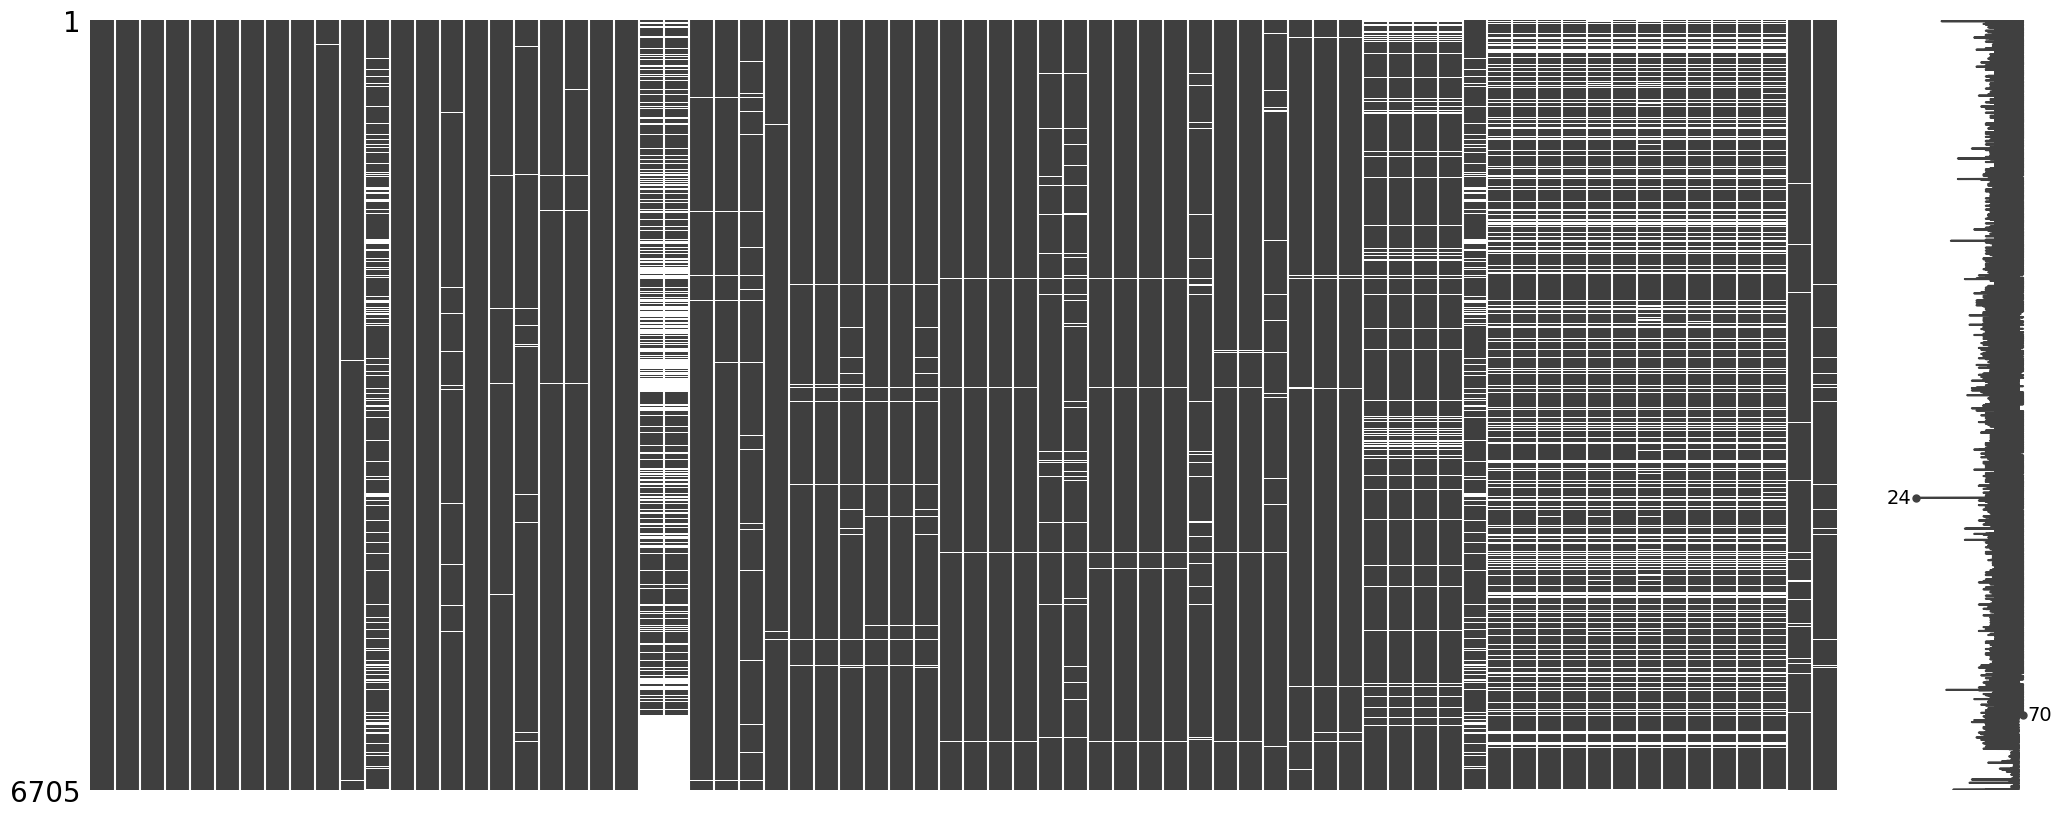

In [109]:
msno.matrix(data)

In [110]:
((data.isna()).sum()).to_frame(name='null count').T

,ID_Aluno,Momento,Local_de_Avaliacao,Data_avaliacao,Data_nascimento,Age,Genero,Modalidade,Freq_semanal,ANTROPOMETRIA_Estatura_cm,ANTROPOMETRIA_Peso_Kg,Escolaridade,Quedas_ultimos_12meses,Quedas_12meses_Quantas,Quedas_12meses_Situacao,Quedas_12meses_Lesao_Sim_Nao,Quedas_12meses_Lesao_Tipo,Quedas_12meses_Lesao_Local,Quedas_12meses_Assistencia_hospitalar_Sim_Não,Quedas_12meses_Hospitalizado_Sim_Não,Quedas_12meses_Hospitalizado_Dias,Quedas_12meses_Medo_cair_Sim_Não,ATIVIDADE_FISICA_Geral_Sim_Não,ATIVIDADE_FISICA_Caminhada_Frequência_Dias_semana,ANTROPOMETRIA_Massa_gorda,ANTROPOMETRIA_Massa_magra_Kg,ANTROPOMETRIA_Gordura_visceral,HANDGRIP_Mao_DOMINANTE,HANDGRIP_DIREITA_tentaiva1,HANDGRIP_DIREITA_tentativa2,HANDGRIP_DIREITA_tentativa_3,HANDGRIP_ESQUERDA_tentativa1,HANDGRIP_ESQUERDA_tentativa2,HANDGRIP_ESQUERDA_tentativa3,TIMED_UP_AND_GO_Simples_tentativa1,TIMED_UP_AND_GO_Simples_tentativa2,Best_TIMED_UP_AND_GO_Simples,Percentil_TIMED_UP_AND_GO_Simples,TIMED_UP_AND_GO_Simples_Apoio_mãos,TIMED_UP_AND_GO_Simples_Auxiliar_marcha,TIMED_UP_AND_GO_Dupla_tarefa_tentativa1,TIMED_UP_AND_GO_Dupla_tarefa_tentativa2,Best_TIMED_UP_AND_GO_Dupla_tarefa,Percentil_TIMED_UP_AND_GO_Dupla_tarefa,TIMED_UP_AND_GO_Dupla_tarefa_Apoio_maos,SIT_TO_STAND_Repetiçoes,Percentil_SIT_TO_STAND_Repetiçoes,SIT_TO_STAND_Apoio_maos,@6_MIN_ANDAR_N_voltas_completas,@6_MIN_ANDAR_Distancia_TOTAL_metros,Percentil_@6_MIN_ANDAR_Distancia_TOTAL_metros,@6_MIN_ANDAR_Parou,@6_MIN_ANDAR_Parou_Quantas_vezes,@6_MIN_ANDAR_Parou_Motivo,@6_MIN_ANDAR_Desistiu,MMSE_EDUCAÇAO,MMSE_ORIENTACAO_TEMPORAL,MMSE_ORIENTACAO_ESPACIAL,MMSE_ATENCAO_CALCULO,MMSE_LINGUAGEM_C_COMANDO,MMSE_LINGUAGEM_E_FRASE_ESCRITA,MMSE_COPIA_DESENHO_1,MMSE_Total,EQ5D5L_MOBILIDADE,EQ5D5L_CUIDADOS_PESSOAIS,EQ5D5L_ATIVIDADES_HABITUAIS,EQ5D5L_DOR_MAL_ESTAR,EQ5D5L_ANSIEDADE_DEPRESSAO,EQ5D5L_A_sua_saude_hoje_0_100,HANDGRIP_DIREITA_tentativa_2
null count,0,0,0,0,0,0,0,2,2,32,10,889,0,0,119,0,57,102,40,46,0,0,2602,2596,35,37,242,30,49,51,102,59,61,109,31,38,31,31,114,265,39,49,39,39,199,44,44,139,77,99,99,615,615,633,633,889,1450,1449,1454,1458,1474,1454,1580,1453,1452,1454,1451,1456,164,102


In [111]:
print(data.shape)

(6705, 70)


## Imputação

In [112]:
missing_ratios = data.isna().mean()

missing_cols_0_5 = missing_ratios[missing_ratios < treshold1].index.tolist()
missing_cols_5_20 = missing_ratios[(missing_ratios < treshold2) & (missing_ratios > treshold1)].index.tolist()
missing_cols_20_40 = missing_ratios[(missing_ratios < treshold3) & (missing_ratios > treshold2)].index.tolist()
missing_cols_40_100 = missing_ratios[missing_ratios > treshold3].index.tolist()

print("missing_cols_40_100:", missing_cols_40_100)
print("missing_cols_20_40:", missing_cols_20_40)
print("missing_cols_5_20", missing_cols_5_20)
print("missing_cols_0_5:", missing_cols_0_5)

missing_cols_40_100: []
missing_cols_20_40: ['ATIVIDADE_FISICA_Geral_Sim_Não', 'ATIVIDADE_FISICA_Caminhada_Frequência_Dias_semana', 'MMSE_ORIENTACAO_TEMPORAL', 'MMSE_ORIENTACAO_ESPACIAL', 'MMSE_ATENCAO_CALCULO', 'MMSE_LINGUAGEM_C_COMANDO', 'MMSE_LINGUAGEM_E_FRASE_ESCRITA', 'MMSE_COPIA_DESENHO_1', 'MMSE_Total', 'EQ5D5L_MOBILIDADE', 'EQ5D5L_CUIDADOS_PESSOAIS', 'EQ5D5L_ATIVIDADES_HABITUAIS', 'EQ5D5L_DOR_MAL_ESTAR', 'EQ5D5L_ANSIEDADE_DEPRESSAO']
missing_cols_5_20 ['Escolaridade', '@6_MIN_ANDAR_Parou', '@6_MIN_ANDAR_Parou_Quantas_vezes', '@6_MIN_ANDAR_Parou_Motivo', '@6_MIN_ANDAR_Desistiu', 'MMSE_EDUCAÇAO']
missing_cols_0_5: ['ID_Aluno', 'Momento', 'Local_de_Avaliacao', 'Data_avaliacao', 'Data_nascimento', 'Age', 'Genero', 'Modalidade', 'Freq_semanal', 'ANTROPOMETRIA_Estatura_cm', 'ANTROPOMETRIA_Peso_Kg', 'Quedas_ultimos_12meses', 'Quedas_12meses_Quantas', 'Quedas_12meses_Situacao', 'Quedas_12meses_Lesao_Sim_Nao', 'Quedas_12meses_Lesao_Tipo', 'Quedas_12meses_Lesao_Local', 'Quedas_12meses_As

In [113]:
missing_cols_5_20.remove("@6_MIN_ANDAR_Parou_Motivo")
missing_cols_5_20.remove("@6_MIN_ANDAR_Desistiu")
missing_cols_0_5.remove("Quedas_12meses_Situacao")
missing_cols_0_5.remove("Quedas_12meses_Lesao_Tipo")
missing_cols_0_5.remove("Quedas_12meses_Lesao_Local")
missing_cols_0_5.remove("Data_avaliacao")
missing_cols_0_5.remove("Data_nascimento")


In [114]:
columns_to_imput = missing_cols_20_40 + missing_cols_5_20 + missing_cols_0_5
data_to_impute = data[columns_to_imput]

imputer = KNNImputer(n_neighbors=10)
imputed_array = imputer.fit_transform(data_to_impute)

data[columns_to_imput] = imputed_array


if 'TIMED_UP_AND_GO_Dupla_tarefa_Auxiliar_marcha' in binary_columns:
    binary_columns.remove('TIMED_UP_AND_GO_Dupla_tarefa_Auxiliar_marcha')
    binary_columns.remove('SIT_TO_STAND_Auxiliar_marcha')
    binary_columns.remove('@6_MIN_ANDAR_Auxiliar_marcha')

    discrete_columns.remove("MMSE_RETENCAO")
    discrete_columns.remove("MMSE_EVOCACAO_1")
    discrete_columns.remove("MMSE_LINGUAGEM_A_NOMEACAO")
    discrete_columns.remove("ATIVIDADE_FISICA_Outras_AF_Frequencia_Dias_semana")

    ordinal_columns.remove("ATIVIDADE_FISICA_Caminhada_Intensidade")
    ordinal_columns.remove("ATIVIDADE_FISICA_Outras_AF_Intensidade")

discrete_columns = [c for c in discrete_columns if c in data.columns]
binary_columns = [c for c in binary_columns if c in data.columns]
ordinal_columns = [c for c in ordinal_columns if c in data.columns]

data[binary_columns] = data[binary_columns].round().astype(int)
data[discrete_columns] = data[discrete_columns].round().astype(int)
data[ordinal_columns] = data[ordinal_columns].round().astype(int)

<Axes: >

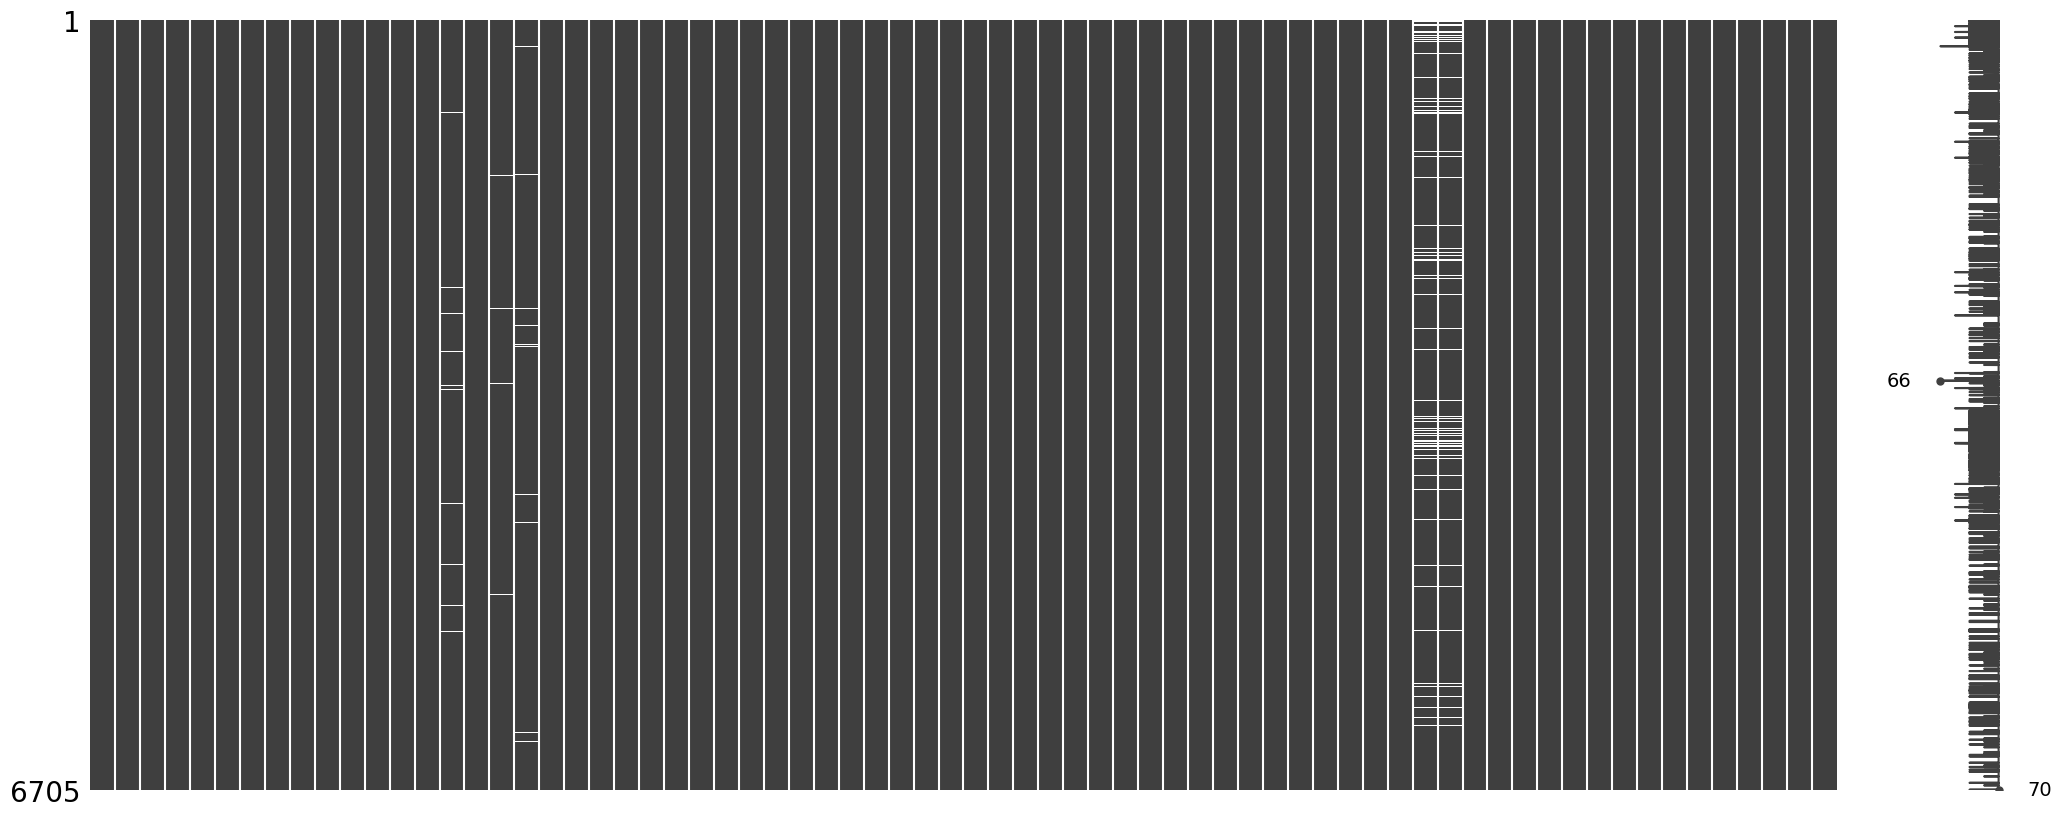

In [115]:
msno.matrix(data)

In [116]:
((data.isna()).sum()).to_frame(name='null count').T

,ID_Aluno,Momento,Local_de_Avaliacao,Data_avaliacao,Data_nascimento,Age,Genero,Modalidade,Freq_semanal,ANTROPOMETRIA_Estatura_cm,ANTROPOMETRIA_Peso_Kg,Escolaridade,Quedas_ultimos_12meses,Quedas_12meses_Quantas,Quedas_12meses_Situacao,Quedas_12meses_Lesao_Sim_Nao,Quedas_12meses_Lesao_Tipo,Quedas_12meses_Lesao_Local,Quedas_12meses_Assistencia_hospitalar_Sim_Não,Quedas_12meses_Hospitalizado_Sim_Não,Quedas_12meses_Hospitalizado_Dias,Quedas_12meses_Medo_cair_Sim_Não,ATIVIDADE_FISICA_Geral_Sim_Não,ATIVIDADE_FISICA_Caminhada_Frequência_Dias_semana,ANTROPOMETRIA_Massa_gorda,ANTROPOMETRIA_Massa_magra_Kg,ANTROPOMETRIA_Gordura_visceral,HANDGRIP_Mao_DOMINANTE,HANDGRIP_DIREITA_tentaiva1,HANDGRIP_DIREITA_tentativa2,HANDGRIP_DIREITA_tentativa_3,HANDGRIP_ESQUERDA_tentativa1,HANDGRIP_ESQUERDA_tentativa2,HANDGRIP_ESQUERDA_tentativa3,TIMED_UP_AND_GO_Simples_tentativa1,TIMED_UP_AND_GO_Simples_tentativa2,Best_TIMED_UP_AND_GO_Simples,Percentil_TIMED_UP_AND_GO_Simples,TIMED_UP_AND_GO_Simples_Apoio_mãos,TIMED_UP_AND_GO_Simples_Auxiliar_marcha,TIMED_UP_AND_GO_Dupla_tarefa_tentativa1,TIMED_UP_AND_GO_Dupla_tarefa_tentativa2,Best_TIMED_UP_AND_GO_Dupla_tarefa,Percentil_TIMED_UP_AND_GO_Dupla_tarefa,TIMED_UP_AND_GO_Dupla_tarefa_Apoio_maos,SIT_TO_STAND_Repetiçoes,Percentil_SIT_TO_STAND_Repetiçoes,SIT_TO_STAND_Apoio_maos,@6_MIN_ANDAR_N_voltas_completas,@6_MIN_ANDAR_Distancia_TOTAL_metros,Percentil_@6_MIN_ANDAR_Distancia_TOTAL_metros,@6_MIN_ANDAR_Parou,@6_MIN_ANDAR_Parou_Quantas_vezes,@6_MIN_ANDAR_Parou_Motivo,@6_MIN_ANDAR_Desistiu,MMSE_EDUCAÇAO,MMSE_ORIENTACAO_TEMPORAL,MMSE_ORIENTACAO_ESPACIAL,MMSE_ATENCAO_CALCULO,MMSE_LINGUAGEM_C_COMANDO,MMSE_LINGUAGEM_E_FRASE_ESCRITA,MMSE_COPIA_DESENHO_1,MMSE_Total,EQ5D5L_MOBILIDADE,EQ5D5L_CUIDADOS_PESSOAIS,EQ5D5L_ATIVIDADES_HABITUAIS,EQ5D5L_DOR_MAL_ESTAR,EQ5D5L_ANSIEDADE_DEPRESSAO,EQ5D5L_A_sua_saude_hoje_0_100,HANDGRIP_DIREITA_tentativa_2
null count,0,0,0,0,0,0,0,0,0,0,0,0,0,0,119,0,57,102,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,633,633,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## Fill text variables with "doesn't know"

In [124]:
def fill_text_variables(df):
    df.loc[df['Quedas_12meses_Situacao'].isnull(), 'Quedas_12meses_Situacao'] = "não sabe"
    df.loc[df['Quedas_12meses_Lesao_Tipo'].isnull(), 'Quedas_12meses_Lesao_Tipo'] = "não sabe"
    df.loc[df['Quedas_12meses_Lesao_Local'].isnull(), 'Quedas_12meses_Lesao_Local'] = "não sabe"

    df.loc[(df['@6_MIN_ANDAR_Parou'] == 0) & (df['@6_MIN_ANDAR_Desistiu'].isnull()), '@6_MIN_ANDAR_Desistiu'] = ""
    df.loc[(df['@6_MIN_ANDAR_Parou'] == 0) & (df['@6_MIN_ANDAR_Parou_Motivo'].isnull()), '@6_MIN_ANDAR_Parou_Motivo'] = ""

    df.loc[(df['@6_MIN_ANDAR_Parou'] == 1) & (df['@6_MIN_ANDAR_Desistiu'].isnull()), '@6_MIN_ANDAR_Desistiu'] = "não sabe"
    df.loc[(df['@6_MIN_ANDAR_Parou'] == 1) & (df['@6_MIN_ANDAR_Parou_Motivo'].isnull()), '@6_MIN_ANDAR_Parou_Motivo'] = "não sabe"

    data.loc[data['Quedas_ultimos_12meses'] == 0, 'Quedas_12meses_Situacao'] = ""


    ## other fix
    df.loc[(df['@6_MIN_ANDAR_Distancia_TOTAL_metros'] == 0) & (df['@6_MIN_ANDAR_N_voltas_completas'] != 0), '@6_MIN_ANDAR_Distancia_TOTAL_metros'] = df["@6_MIN_ANDAR_N_voltas_completas"] * 50
    df.loc[(df['Quedas_12meses_Hospitalizado_Sim_Não'] == 0) & (df['Quedas_12meses_Hospitalizado_Dias'] != 0), 'Quedas_12meses_Hospitalizado_Dias'] = 0

    return df

data = fill_text_variables(data)

<Axes: >

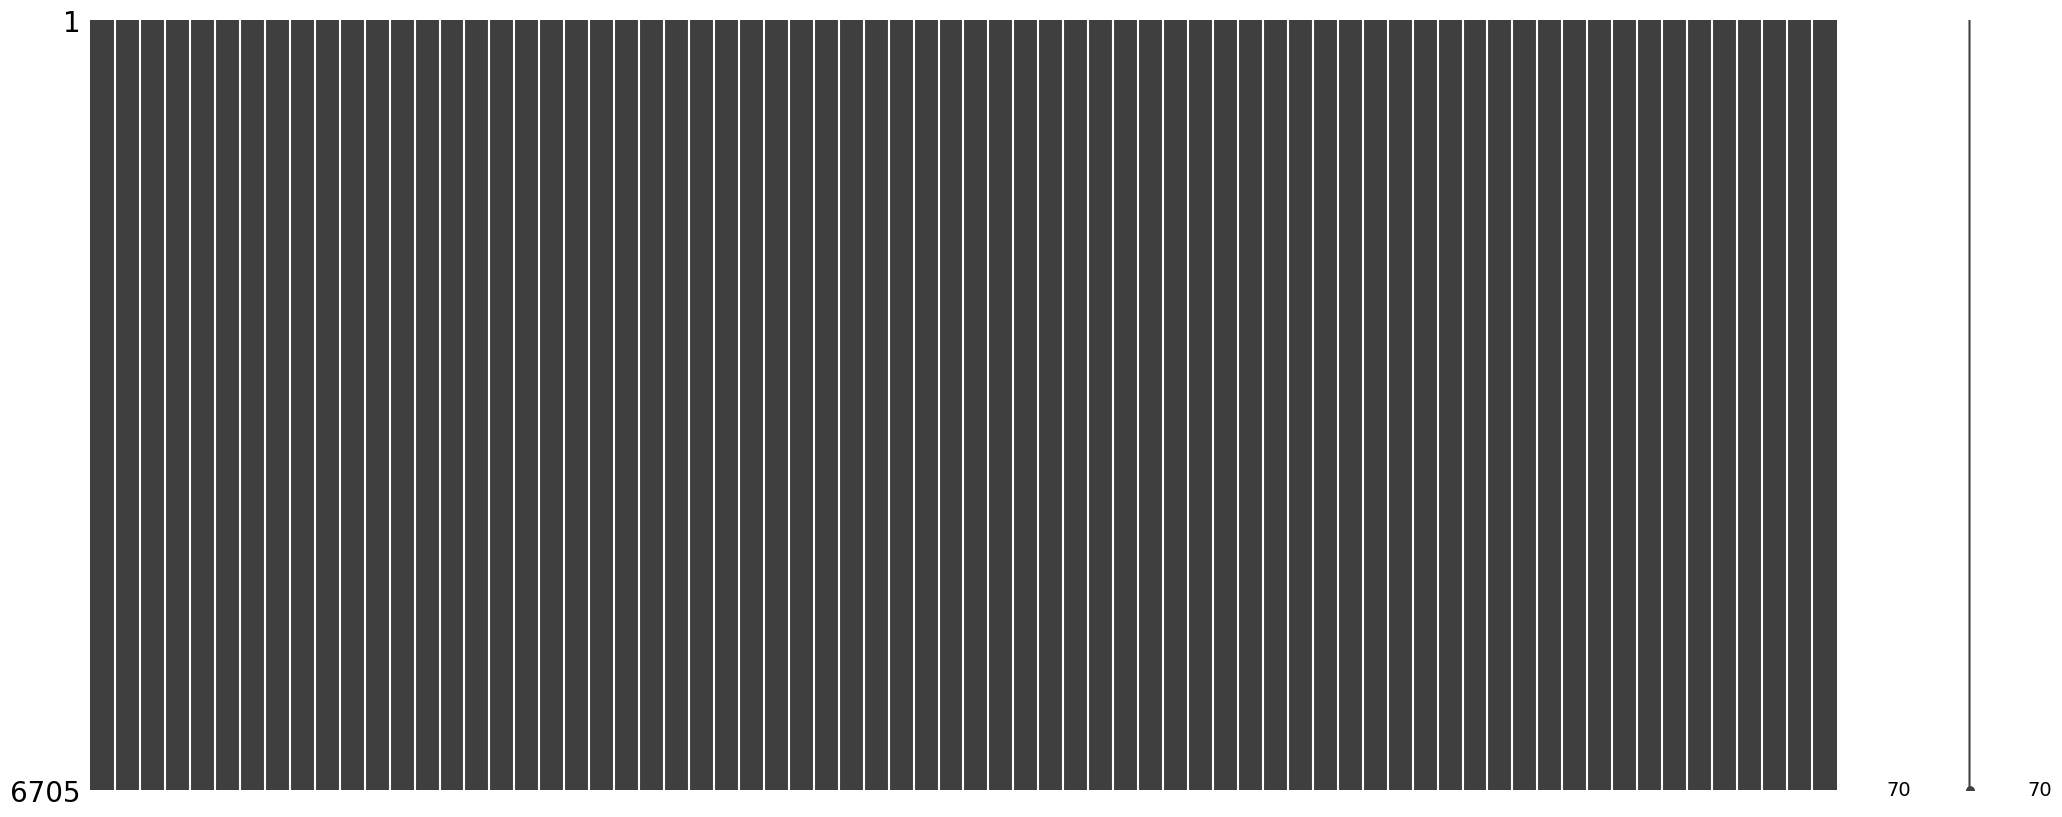

In [125]:
msno.matrix(data)

In [126]:
((data.isna()).sum()).to_frame(name='null count').T

,ID_Aluno,Momento,Local_de_Avaliacao,Data_avaliacao,Data_nascimento,Age,Genero,Modalidade,Freq_semanal,ANTROPOMETRIA_Estatura_cm,ANTROPOMETRIA_Peso_Kg,Escolaridade,Quedas_ultimos_12meses,Quedas_12meses_Quantas,Quedas_12meses_Situacao,Quedas_12meses_Lesao_Sim_Nao,Quedas_12meses_Lesao_Tipo,Quedas_12meses_Lesao_Local,Quedas_12meses_Assistencia_hospitalar_Sim_Não,Quedas_12meses_Hospitalizado_Sim_Não,Quedas_12meses_Hospitalizado_Dias,Quedas_12meses_Medo_cair_Sim_Não,ATIVIDADE_FISICA_Geral_Sim_Não,ATIVIDADE_FISICA_Caminhada_Frequência_Dias_semana,ANTROPOMETRIA_Massa_gorda,ANTROPOMETRIA_Massa_magra_Kg,ANTROPOMETRIA_Gordura_visceral,HANDGRIP_Mao_DOMINANTE,HANDGRIP_DIREITA_tentaiva1,HANDGRIP_DIREITA_tentativa2,HANDGRIP_DIREITA_tentativa_3,HANDGRIP_ESQUERDA_tentativa1,HANDGRIP_ESQUERDA_tentativa2,HANDGRIP_ESQUERDA_tentativa3,TIMED_UP_AND_GO_Simples_tentativa1,TIMED_UP_AND_GO_Simples_tentativa2,Best_TIMED_UP_AND_GO_Simples,Percentil_TIMED_UP_AND_GO_Simples,TIMED_UP_AND_GO_Simples_Apoio_mãos,TIMED_UP_AND_GO_Simples_Auxiliar_marcha,TIMED_UP_AND_GO_Dupla_tarefa_tentativa1,TIMED_UP_AND_GO_Dupla_tarefa_tentativa2,Best_TIMED_UP_AND_GO_Dupla_tarefa,Percentil_TIMED_UP_AND_GO_Dupla_tarefa,TIMED_UP_AND_GO_Dupla_tarefa_Apoio_maos,SIT_TO_STAND_Repetiçoes,Percentil_SIT_TO_STAND_Repetiçoes,SIT_TO_STAND_Apoio_maos,@6_MIN_ANDAR_N_voltas_completas,@6_MIN_ANDAR_Distancia_TOTAL_metros,Percentil_@6_MIN_ANDAR_Distancia_TOTAL_metros,@6_MIN_ANDAR_Parou,@6_MIN_ANDAR_Parou_Quantas_vezes,@6_MIN_ANDAR_Parou_Motivo,@6_MIN_ANDAR_Desistiu,MMSE_EDUCAÇAO,MMSE_ORIENTACAO_TEMPORAL,MMSE_ORIENTACAO_ESPACIAL,MMSE_ATENCAO_CALCULO,MMSE_LINGUAGEM_C_COMANDO,MMSE_LINGUAGEM_E_FRASE_ESCRITA,MMSE_COPIA_DESENHO_1,MMSE_Total,EQ5D5L_MOBILIDADE,EQ5D5L_CUIDADOS_PESSOAIS,EQ5D5L_ATIVIDADES_HABITUAIS,EQ5D5L_DOR_MAL_ESTAR,EQ5D5L_ANSIEDADE_DEPRESSAO,EQ5D5L_A_sua_saude_hoje_0_100,HANDGRIP_DIREITA_tentativa_2
null count,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [127]:
mask = (data['Quedas_ultimos_12meses'] == 0) & (data['Quedas_12meses_Situacao'] != "")
erro_rows = data[mask]

print("Linhas com erro (Quedas_12meses_Situacao):")
display(erro_rows)   # ou print(erro_rows) se não estiveres num notebook

Linhas com erro (Quedas_12meses_Situacao):


,ID_Aluno,Momento,Local_de_Avaliacao,Data_avaliacao,Data_nascimento,Age,Genero,Modalidade,Freq_semanal,ANTROPOMETRIA_Estatura_cm,ANTROPOMETRIA_Peso_Kg,Escolaridade,Quedas_ultimos_12meses,Quedas_12meses_Quantas,Quedas_12meses_Situacao,Quedas_12meses_Lesao_Sim_Nao,Quedas_12meses_Lesao_Tipo,Quedas_12meses_Lesao_Local,Quedas_12meses_Assistencia_hospitalar_Sim_Não,Quedas_12meses_Hospitalizado_Sim_Não,Quedas_12meses_Hospitalizado_Dias,Quedas_12meses_Medo_cair_Sim_Não,ATIVIDADE_FISICA_Geral_Sim_Não,ATIVIDADE_FISICA_Caminhada_Frequência_Dias_semana,ANTROPOMETRIA_Massa_gorda,ANTROPOMETRIA_Massa_magra_Kg,ANTROPOMETRIA_Gordura_visceral,HANDGRIP_Mao_DOMINANTE,HANDGRIP_DIREITA_tentaiva1,HANDGRIP_DIREITA_tentativa2,HANDGRIP_DIREITA_tentativa_3,HANDGRIP_ESQUERDA_tentativa1,HANDGRIP_ESQUERDA_tentativa2,HANDGRIP_ESQUERDA_tentativa3,TIMED_UP_AND_GO_Simples_tentativa1,TIMED_UP_AND_GO_Simples_tentativa2,Best_TIMED_UP_AND_GO_Simples,Percentil_TIMED_UP_AND_GO_Simples,TIMED_UP_AND_GO_Simples_Apoio_mãos,TIMED_UP_AND_GO_Simples_Auxiliar_marcha,TIMED_UP_AND_GO_Dupla_tarefa_tentativa1,TIMED_UP_AND_GO_Dupla_tarefa_tentativa2,Best_TIMED_UP_AND_GO_Dupla_tarefa,Percentil_TIMED_UP_AND_GO_Dupla_tarefa,TIMED_UP_AND_GO_Dupla_tarefa_Apoio_maos,SIT_TO_STAND_Repetiçoes,Percentil_SIT_TO_STAND_Repetiçoes,SIT_TO_STAND_Apoio_maos,@6_MIN_ANDAR_N_voltas_completas,@6_MIN_ANDAR_Distancia_TOTAL_metros,Percentil_@6_MIN_ANDAR_Distancia_TOTAL_metros,@6_MIN_ANDAR_Parou,@6_MIN_ANDAR_Parou_Quantas_vezes,@6_MIN_ANDAR_Parou_Motivo,@6_MIN_ANDAR_Desistiu,MMSE_EDUCAÇAO,MMSE_ORIENTACAO_TEMPORAL,MMSE_ORIENTACAO_ESPACIAL,MMSE_ATENCAO_CALCULO,MMSE_LINGUAGEM_C_COMANDO,MMSE_LINGUAGEM_E_FRASE_ESCRITA,MMSE_COPIA_DESENHO_1,MMSE_Total,EQ5D5L_MOBILIDADE,EQ5D5L_CUIDADOS_PESSOAIS,EQ5D5L_ATIVIDADES_HABITUAIS,EQ5D5L_DOR_MAL_ESTAR,EQ5D5L_ANSIEDADE_DEPRESSAO,EQ5D5L_A_sua_saude_hoje_0_100,HANDGRIP_DIREITA_tentativa_2


## Verifications

In [128]:
def verification_func(df):
    # Quedas_ultimos_12meses and Quedas_12meses_Quantas
    if ((df['Quedas_ultimos_12meses'] == 0) & (df['Quedas_12meses_Quantas'] > 0)).any():
        raise ValueError("error Quedas_ultimos_12meses and Quedas_12meses_Quantas")
    
    if ((df['Quedas_ultimos_12meses'] == 1) & (df['Quedas_12meses_Quantas'] == 0)).any():
        raise ValueError("error Quedas_ultimos_12meses and Quedas_12meses_Quantas")
    
    # Quedas_12meses_Situacao
    if ((df['Quedas_ultimos_12meses'] == 0) & (df['Quedas_12meses_Situacao'] != "")).any():
        raise ValueError("error Quedas_12meses_Situacao 1")
    
    if ((df['Quedas_ultimos_12meses'] == 1) & (df['Quedas_12meses_Situacao'] == "")).any():
        raise ValueError("error Quedas_12meses_Situacao 2")
    
    # Quedas_12meses_Lesao_Sim_Nao
    if ((df['Quedas_ultimos_12meses'] == 0) & (df['Quedas_12meses_Lesao_Sim_Nao'] == 1)).any():
        raise ValueError("error Quedas_12meses_Lesao_Sim_Nao")
    
    # Quedas_12meses_Lesao_Tipo	Quedas_12meses_Lesao_Local
    if ((df['Quedas_12meses_Lesao_Sim_Nao'] == 0) & (df['Quedas_12meses_Lesao_Tipo'] != "")).any():
        raise ValueError("error Quedas_12meses_Lesao_Tipo	Quedas_12meses_Lesao_Local	")
    
    if ((df['Quedas_12meses_Lesao_Sim_Nao'] == 0) & (df['Quedas_12meses_Lesao_Local'] != "")).any():
        raise ValueError("error Quedas_12meses_Lesao_Tipo	Quedas_12meses_Lesao_Local	")
    
    if ((df['Quedas_12meses_Lesao_Tipo'] != "") & (df['Quedas_12meses_Lesao_Sim_Nao'] == 0)).any():
        raise ValueError("error Quedas_12meses_Lesao_Tipo	Quedas_12meses_Lesao_Local	")
    
    if ((df['Quedas_12meses_Lesao_Local'] != "") & (df['Quedas_12meses_Lesao_Sim_Nao'] == 0)).any():
        raise ValueError("error Quedas_12meses_Lesao_Tipo	Quedas_12meses_Lesao_Local	")
    
    # Quedas_12meses_Assistencia_hospitalar_Sim_Não
    if ((df['Quedas_12meses_Lesao_Sim_Nao'] == 0) & (df['Quedas_12meses_Assistencia_hospitalar_Sim_Não'] == 1)).any():
        raise ValueError("error Quedas_12meses_Assistencia_hospitalar_Sim_Não")
    
    # Quedas_12meses_Hospitalizado_Sim_Não
    if ((df['Quedas_12meses_Assistencia_hospitalar_Sim_Não'] == 0) & (df['Quedas_12meses_Hospitalizado_Sim_Não'] == 1)).any():
        raise ValueError("error Quedas_12meses_Hospitalizado_Sim_Não")
    
    # Quedas_12meses_Hospitalizado_Dias
    if ((df['Quedas_12meses_Hospitalizado_Sim_Não'] == 0) & (df['Quedas_12meses_Hospitalizado_Dias'] > 0)).any():
        raise ValueError("error Quedas_12meses_Hospitalizado_Dias")
    
    if ((df['Quedas_12meses_Hospitalizado_Sim_Não'] != 0) & (df['Quedas_12meses_Hospitalizado_Dias'] == 0)).any():
        raise ValueError("error Quedas_12meses_Hospitalizado_Dias")
    
    # @6_MIN_ANDAR_Parou	@6_MIN_ANDAR_Parou_Quantas_vezes
    if ((df['@6_MIN_ANDAR_Parou'] == 0) & (df['@6_MIN_ANDAR_Parou_Quantas_vezes'] > 0)).any():
        raise ValueError("error 6_MIN_ANDAR_Parou_Quantas_vezes")
    
    if ((df['@6_MIN_ANDAR_Parou'] != 0) & (df['@6_MIN_ANDAR_Parou_Quantas_vezes'] == 0)).any():
        raise ValueError("error 6_MIN_ANDAR_Parou_Quantas_vezes")
    

    # @6_MIN_ANDAR_Parou_Motivo	@6_MIN_ANDAR_Desistiu
    if ((df['@6_MIN_ANDAR_Parou'] == 0) & (df['@6_MIN_ANDAR_Parou_Motivo'] != "")).any():
        raise ValueError("error @6_MIN_ANDAR_Parou_Motivo	@6_MIN_ANDAR_Desistiu")
    
    if ((df['@6_MIN_ANDAR_Parou'] == 0) & (df['@6_MIN_ANDAR_Desistiu'] != "")).any():
        raise ValueError("error @6_MIN_ANDAR_Parou_Motivo	@6_MIN_ANDAR_Desistiu")
    
    if ((df['@6_MIN_ANDAR_Desistiu'] != "") & (df['@6_MIN_ANDAR_Parou'] == 0)).any():
        raise ValueError("error @6_MIN_ANDAR_Parou_Motivo	@6_MIN_ANDAR_Desistiu")
    
    if ((df['@6_MIN_ANDAR_Parou_Motivo'] != "") & (df['@6_MIN_ANDAR_Parou'] == 0)).any():
        raise ValueError("error @6_MIN_ANDAR_Parou_Motivo	@6_MIN_ANDAR_Desistiu")
    

    return "data is good!"

verification_func(data)

'data is good!'

## Data dtypes

In [129]:
for i in data.columns:
    print(i+": ",data[i].dtype)

ID_Aluno:  float64
Momento:  float64
Local_de_Avaliacao:  float64
Data_avaliacao:  object
Data_nascimento:  object
Age:  float64
Genero:  int32
Modalidade:  float64
Freq_semanal:  int32
ANTROPOMETRIA_Estatura_cm:  float64
ANTROPOMETRIA_Peso_Kg:  float64
Escolaridade:  int32
Quedas_ultimos_12meses:  int32
Quedas_12meses_Quantas:  int32
Quedas_12meses_Situacao:  object
Quedas_12meses_Lesao_Sim_Nao:  int32
Quedas_12meses_Lesao_Tipo:  object
Quedas_12meses_Lesao_Local:  object
Quedas_12meses_Assistencia_hospitalar_Sim_Não:  int32
Quedas_12meses_Hospitalizado_Sim_Não:  int32
Quedas_12meses_Hospitalizado_Dias:  float64
Quedas_12meses_Medo_cair_Sim_Não:  int32
ATIVIDADE_FISICA_Geral_Sim_Não:  int32
ATIVIDADE_FISICA_Caminhada_Frequência_Dias_semana:  int32
ANTROPOMETRIA_Massa_gorda:  float64
ANTROPOMETRIA_Massa_magra_Kg:  float64
ANTROPOMETRIA_Gordura_visceral:  float64
HANDGRIP_Mao_DOMINANTE:  int32
HANDGRIP_DIREITA_tentaiva1:  float64
HANDGRIP_DIREITA_tentativa2:  float64
HANDGRIP_DIREITA_te

In [130]:
def change_d_types(df):
    data["ID_Aluno"] = data["ID_Aluno"].astype(int)
    data["Momento"] = data["Momento"].astype(int)
    data["Local_de_Avaliacao"] = data["Local_de_Avaliacao"].astype(int)
    data["Age"] = data["Age"].astype(int)
    data["Modalidade"] = data["Modalidade"].astype(int)
    data["Quedas_12meses_Hospitalizado_Dias"] = data["Quedas_12meses_Hospitalizado_Dias"].astype(int)
    data["SIT_TO_STAND_Repetiçoes"] = data["SIT_TO_STAND_Repetiçoes"].astype(int)
    data["@6_MIN_ANDAR_N_voltas_completas"] = data["@6_MIN_ANDAR_N_voltas_completas"].astype(int)
    data["@6_MIN_ANDAR_Distancia_TOTAL_metros"] = data["@6_MIN_ANDAR_Distancia_TOTAL_metros"].astype(int)
    data["MMSE_Total"] = data["MMSE_Total"].astype(int)
    data["EQ5D5L_A_sua_saude_hoje_0_100"] = data["EQ5D5L_A_sua_saude_hoje_0_100"].astype(int)

    return df

data = change_d_types(data)

## Save dataset

In [131]:
data.to_csv("../data/interim/07. FRAIL_null_treatment.csv", index=False)